In [23]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import os

import sys
sys.path.append('../../')
import analysis_utils as utils

utils.load_plotting_setting()

In [24]:
import importlib
importlib.reload(utils)

<module 'analysis_utils' from '/Users/yuhan/work/nanospheres/gas_collisions/analysis_notebooks/sphere_20260215_final_analysis/../../analysis_utils.py'>

## PSD Voigt fit diagnostics — gas run files

For each processed gas HDF5 file the script saves:
- `sv_z` / `ffz` — Welch PSD and frequency array  
- `voigt_params` — `[A, ω₀, σ, γ]` (rad/s) from the resonance fit  
- `sv_imp` — off-resonance imprecision noise floor (V²/Hz)

The cells below overlay the measured PSD, the stored Voigt fit, and the `sv_imp` noise floor for a representative selection of files.

In [25]:
sphere   = 'sphere_20260215'
gas_dir  = rf'/Users/yuhan/work/nanospheres/gas_collisions/data_processed/gas_data_processed/{sphere}'
prefix   = '20260219_dfg_'

# One representative file (index) to show per dataset
# Increase n_overlay to show multiple files overlaid in the consistency plot below
sample_file_idx = 4

def load_voigt_data(fpath):
    """Return (ffz, sv_z, voigt_params, sv_imp) from a processed gas HDF5."""
    with h5py.File(fpath, 'r') as f:
        g = f['data_processed']
        return (g['ffz'][:], g['sv_z'][:], g['voigt_params'][:], float(g['sv_imp'][()]))

def plot_psd_voigt(ax, ffz, sv_z, voigt_params, sv_imp, color='steelblue', label='', freq_lim=(30, 80)):
    """Overlay PSD, Voigt fit, and sv_imp noise floor on ax (frequency in kHz)."""
    A, omega0, sigma, gamma_v = voigt_params
    f0_hz = omega0 / (2 * np.pi)

    idx = (ffz >= freq_lim[0] * 1e3) & (ffz <= freq_lim[1] * 1e3)
    ax.semilogy(ffz[idx] / 1e3, sv_z[idx], color=color, lw=1.2, alpha=0.7, label=label)
    ax.semilogy(ffz[idx] / 1e3,
                utils.voigt(ffz[idx] * 2 * np.pi, A, omega0, sigma, gamma_v) + sv_imp,
                '--', color=color, lw=1.8,
                label=fr'Voigt: $f_0$={f0_hz/1e3:.3f} kHz, $\sigma$={sigma/(2*np.pi):.1f} Hz, $\gamma$={gamma_v/(2*np.pi):.2f} Hz')
    # ax.axhline(sv_imp, color=color, lw=2.0, ls=':', alpha=0.85,
    #            label=fr'$S_{{v,\mathrm{{imp}}}}$ = {sv_imp:.2e} V²/Hz')
    ax.set_xlabel('Frequency (kHz)')
    ax.set_ylabel('PSD (V²/Hz)')
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(which='both', ls=':', lw=0.5)

### One file per gas type — highest pressure

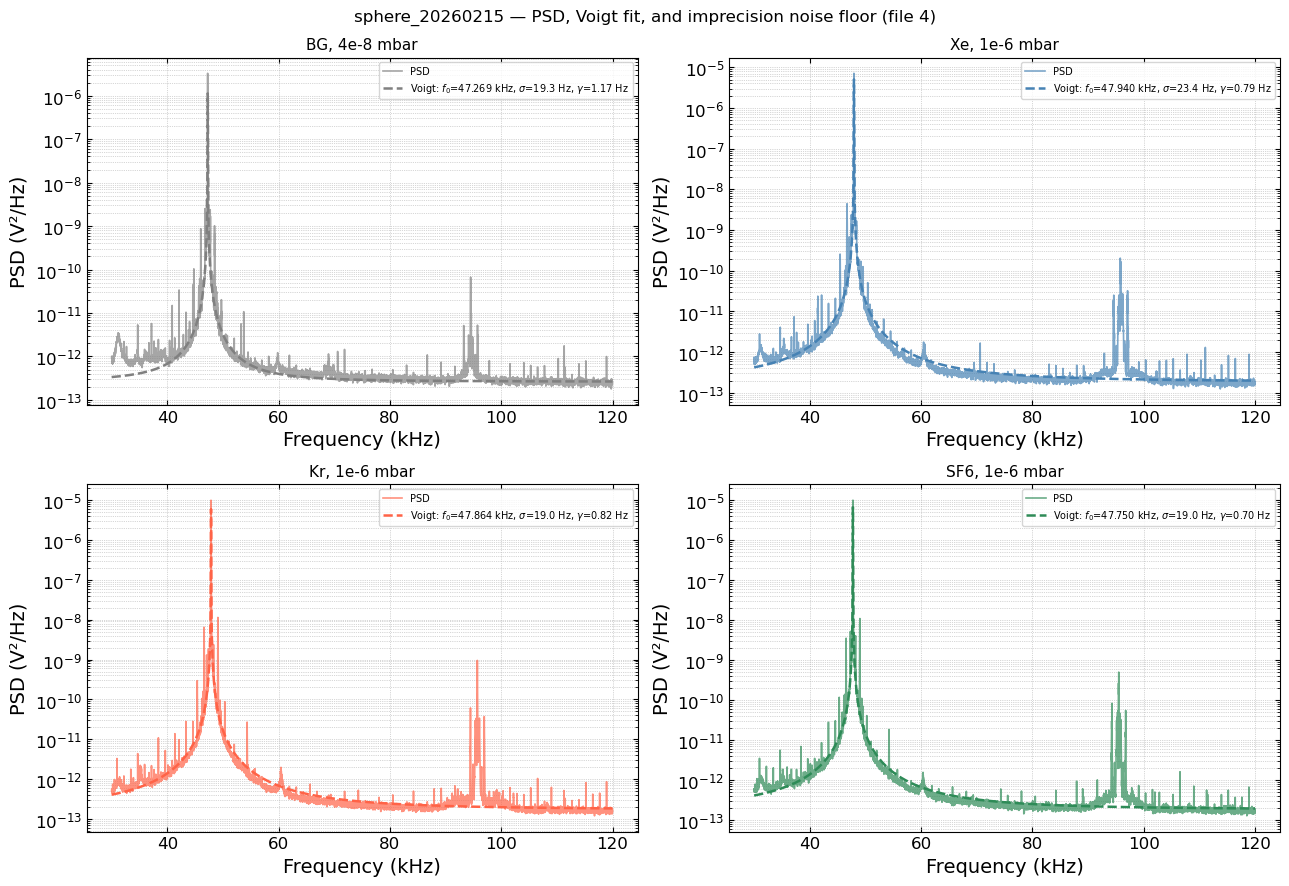

In [26]:
# One file from each gas type (highest-pressure dataset, file index 0)
panels = [
    ('background', 'background_data', '20260219_p6e_4e-8mbar',  'BG, 4e-8 mbar'),
    ('xenon',      'xenon_data',      '20260219_p6e_1e-6mbar',  'Xe, 1e-6 mbar'),
    ('krypton',    'krypton_data',    '20260219_p6e_1e-6mbar',  'Kr, 1e-6 mbar'),
    ('sf6',        'sf6_data',        '20260219_p6e_1e-6mbar',  'SF6, 1e-6 mbar'),
]

colors = ['gray', 'steelblue', 'tomato', 'seagreen']

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, (gas, data_type, dataset, title), color in zip(axes.flatten(), panels, colors):
    fpath = os.path.join(gas_dir, data_type, dataset,
                         f'{prefix}{sample_file_idx}_processed.hdf5')
    ffz, sv_z, vp, sv_imp = load_voigt_data(fpath)
    plot_psd_voigt(ax, ffz, sv_z, vp, sv_imp, color=color, label='PSD', freq_lim=(30, 120))
    ax.set_title(title, fontsize=11)

fig.suptitle(f'{sphere} — PSD, Voigt fit, and imprecision noise floor (file {sample_file_idx})', fontsize=12)
fig.tight_layout()
plt.show()

### Xenon — all pressures, file 0 overlaid

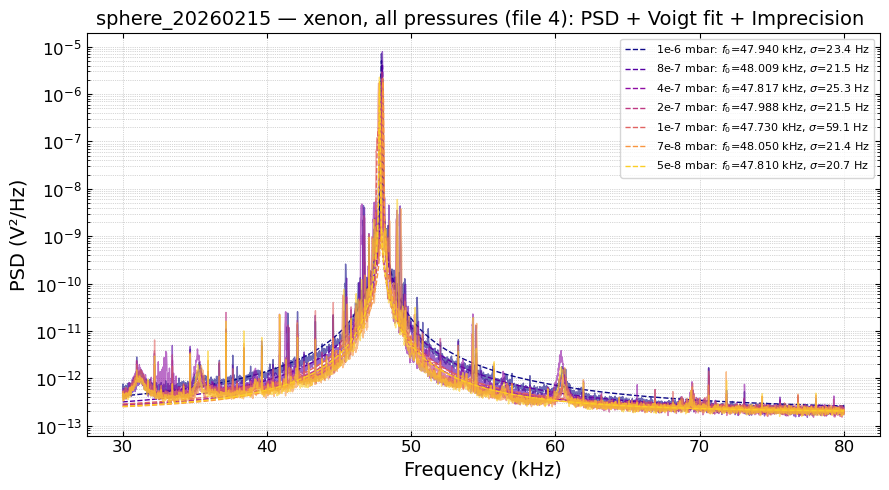

In [27]:
# All xenon pressures — overlay file 0 from each dataset so we can see
# how the resonance peak and noise floor evolve with pressure.
xe_datasets = [
    ('20260219_p6e_1e-6mbar',   '1e-6 mbar'),
    ('20260219_p6e_8e-7mbar',   '8e-7 mbar'),
    ('20260219_p6e_4e-7mbar_1', '4e-7 mbar'),
    ('20260219_p6e_2e-7mbar',   '2e-7 mbar'),
    ('20260219_p6e_1e-7mbar_1', '1e-7 mbar'),
    ('20260219_p6e_7e-8mbar',   '7e-8 mbar'),
    ('20260219_p6e_5e-8mbar',   '5e-8 mbar'),
]

xe_colors = plt.colormaps['plasma'](np.linspace(0, 0.9, len(xe_datasets)))

fig, ax = plt.subplots(figsize=(9, 5))
for (dataset, plabel), color in zip(xe_datasets, xe_colors):
    fpath = os.path.join(gas_dir, 'xenon_data', dataset,
                         f'{prefix}{sample_file_idx}_processed.hdf5')
    if not os.path.exists(fpath):
        print(f'Missing: {fpath}')
        continue
    ffz, sv_z, vp, sv_imp = load_voigt_data(fpath)
    A, omega0, sigma, gamma_v = vp
    idx = (ffz >= 30e3) & (ffz <= 80e3)
    ax.semilogy(ffz[idx] / 1e3, sv_z[idx], color=color, lw=1.0, alpha=0.6)
    ax.semilogy(ffz[idx] / 1e3,
                utils.voigt(ffz[idx] * 2 * np.pi, A, omega0, sigma, gamma_v) + sv_imp,
                '--', color=color, lw=1,
                label=fr'{plabel}: $f_0$={omega0/(2*np.pi*1e3):.3f} kHz, $\sigma$={sigma/(2*np.pi):.1f} Hz')
    # ax.axhline(sv_imp, color=color, lw=0.8, ls=':')

ax.set_xlabel('Frequency (kHz)')
ax.set_ylabel('PSD (V²/Hz)')
ax.set_title(f'{sphere} — xenon, all pressures (file {sample_file_idx}): PSD + Voigt fit + Imprecision ')
ax.legend(fontsize=8, loc='upper right')
ax.grid(which='both', ls=':', lw=0.5)
fig.tight_layout()
plt.show()

### Consistency across files — multiple files from one xenon dataset

f0:     mean=47942.57 Hz, std=6.15 Hz
sigma:  mean=22.64 Hz, std=5.38 Hz
gamma:  mean=0.826 Hz, std=0.175 Hz
sv_imp: mean=1.892e-13 V²/Hz, std=9.339e-15 V²/Hz


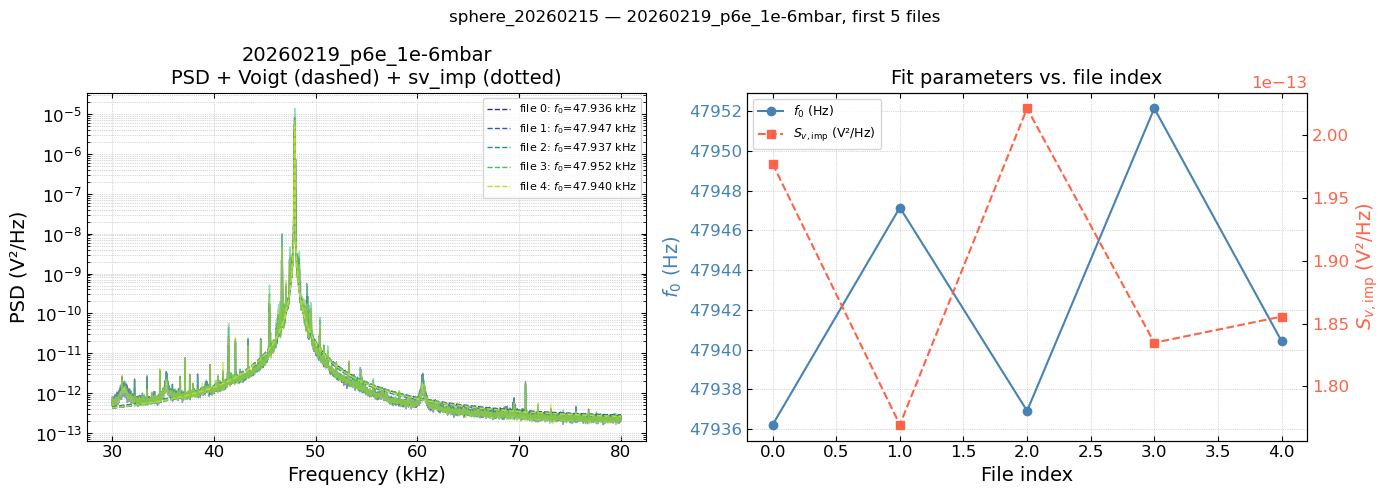

In [28]:
# Overlay the first n_overlay files within a single dataset to check
# that the Voigt fit and sv_imp are stable across files in the same run.
n_overlay  = 5
check_gas  = 'xenon_data'
check_ds   = '20260219_p6e_1e-6mbar'

file_colors = plt.colormaps['viridis'](np.linspace(0.1, 0.9, n_overlay))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

f0_vals, sigma_vals, gamma_vals, sv_imp_vals = [], [], [], []

for i, color in enumerate(file_colors):
    fpath = os.path.join(gas_dir, check_gas, check_ds,
                         f'{prefix}{i}_processed.hdf5')
    ffz, sv_z, vp, sv_imp = load_voigt_data(fpath)
    A, omega0, sigma, gamma_v = vp

    f0_vals.append(omega0 / (2 * np.pi))
    sigma_vals.append(sigma / (2 * np.pi))
    gamma_vals.append(gamma_v / (2 * np.pi))
    sv_imp_vals.append(sv_imp)

    idx = (ffz >= 30e3) & (ffz <= 80e3)
    label = fr'file {i}: $f_0$={omega0/(2*np.pi*1e3):.3f} kHz'

    axes[0].semilogy(ffz[idx] / 1e3, sv_z[idx], color=color, lw=1.0, alpha=0.55)
    axes[0].semilogy(ffz[idx] / 1e3,
                     utils.voigt(ffz[idx] * 2 * np.pi, A, omega0, sigma, gamma_v) + sv_imp,
                     '--', color=color, lw=1, label=label)
    # axes[0].axhline(sv_imp, color=color, lw=0.8, ls=':', alpha=0.8)

axes[0].set_xlabel('Frequency (kHz)')
axes[0].set_ylabel('PSD (V²/Hz)')
axes[0].set_title(f'{check_ds}\nPSD + Voigt (dashed) + sv_imp (dotted)')
axes[0].legend(fontsize=8)
axes[0].grid(which='both', ls=':', lw=0.5)

# Summary of fit parameters across files
xx = np.arange(n_overlay)
ax2 = axes[1]
ax2.errorbar(xx, f0_vals, fmt='o-', color='steelblue', label=r'$f_0$ (Hz)', capsize=4)
ax2_r = ax2.twinx()
ax2_r.errorbar(xx, sv_imp_vals, fmt='s--', color='tomato', label=r'$S_{v,\mathrm{imp}}$ (V²/Hz)', capsize=4)
ax2.set_xlabel('File index')
ax2.set_ylabel(r'$f_0$ (Hz)', color='steelblue')
ax2_r.set_ylabel(r'$S_{v,\mathrm{imp}}$ (V²/Hz)', color='tomato')
ax2.set_title('Fit parameters vs. file index')
ax2.tick_params(axis='y', labelcolor='steelblue')
ax2_r.tick_params(axis='y', labelcolor='tomato')

lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_r.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, fontsize=9)
ax2.grid(ls=':', lw=0.5)

print(f'f0:     mean={np.mean(f0_vals):.2f} Hz, std={np.std(f0_vals):.2f} Hz')
print(f'sigma:  mean={np.mean(sigma_vals):.2f} Hz, std={np.std(sigma_vals):.2f} Hz')
print(f'gamma:  mean={np.mean(gamma_vals):.3f} Hz, std={np.std(gamma_vals):.3f} Hz')
print(f'sv_imp: mean={np.mean(sv_imp_vals):.3e} V²/Hz, std={np.std(sv_imp_vals):.3e} V²/Hz')

fig.suptitle(f'{sphere} — {check_ds}, first {n_overlay} files', fontsize=12)
fig.tight_layout()
plt.show()

## Calibration pulse reconstruction from xenon dataset

Process the 5 highest-pressure xenon files as if they were calibration data:
load raw HDF5 from LaCie, apply notch + bandpass + Voigt fit, then call
`recon_pulse` on each channel-G trigger. This directly checks whether the
reconstruction gives the correct amplitude independent of the gas data pipeline.

In [53]:
import glob
from scipy.optimize import curve_fit

# ── Parameters — must match process_gas_data.py ───────────────────────────
bandpass_lb        = 35000
bandpass_ub        = 80000
lowpass_order      = 3
notch_freq         = 137000
c_imp_scaling      = 1 / 3
positive_pulse     = True

fit_window_length      = 2**19   # prepulse window for ω₀ estimation
analysis_window_length = 2**18   # window centred on each pulse for reconstruction
search_window_length   = 2**8    # search window for peak amplitude
pulse_length           = 20      # offset inside search window
waveform_half_len      = 1500    # samples on each side of peak to store (~60 µs)

amp2kev_cal  = 14460.84503586    # sphere_20260215 after imprecision
expected_kev = 1046              # 20 V calibration result

# ── All xenon datasets ─────────────────────────────────────────────────────
xe_datasets = [
    ('20260219_p6e_1e-6mbar',   '1e-6 mbar'),
    ('20260219_p6e_8e-7mbar',   '8e-7 mbar'),
    # ('20260219_p6e_4e-7mbar',   '4e-7 mbar'),
    ('20260219_p6e_4e-7mbar_1', '4e-7 mbar (2)'),
    ('20260219_p6e_2e-7mbar',   '2e-7 mbar'),
    # ('20260219_p6e_1e-7mbar',   '1e-7 mbar'),
    ('20260219_p6e_1e-7mbar_1', '1e-7 mbar (2)'),
    ('20260219_p6e_7e-8mbar',   '7e-8 mbar'),
    ('20260219_p6e_5e-8mbar',   '5e-8 mbar'),
]
raw_base = r'/Volumes/LaCie/gas_collisions/xenon_data/sphere_20260215'
n_files  = 5   # raw files to process per dataset

# The pulse sits at analysis_window_length inside amp_lp (from get_analysis_window).
# Restrict the peak search to the same region recon_pulse searches, so gas
# collisions or edge artefacts elsewhere in the 524288-sample array don't win.
_search_lo = analysis_window_length + pulse_length
_search_hi = _search_lo + search_window_length

# ── Reconstruct cal pulses from raw data ──────────────────────────────────
all_amps      = {ds: [] for ds, _ in xe_datasets}
all_waveforms = {ds: [] for ds, _ in xe_datasets}

for dataset, label in xe_datasets:
    data_dir = os.path.join(raw_base, dataset)
    files    = sorted(glob.glob(os.path.join(data_dir, '20260219_dfg_*.hdf5')))[:n_files]
    print(f'\n{label}  ({len(files)} files)')

    for fpath in files:
        dtt, nn  = utils.load_timestreams(fpath, ['D', 'G'])
        fs       = int(np.ceil(1 / dtt))
        zz, dd   = nn[0], nn[1]

        p_fit, sv_imp, _, _ = utils.get_sv_imp(
            fs, zz, fit_band=(44000, 60000), noise_band=(110000, 120000),
            nperseg=2**19, p0=[5e-3, 48381*2*np.pi, 100*2*np.pi, 1*2*np.pi])
        A, omega0, sigma, gamma_v = p_fit
        gamma_damping = gamma_v * 2
        c_imp = (np.pi / (omega0**2 * gamma_damping)) * sv_imp / A * c_imp_scaling

        zz_notched = utils.notch_filtered(zz, fs, f0=notch_freq, q=50)
        zz_bp      = utils.bandpass_filtered(zz_notched, fs, bandpass_lb, bandpass_ub,
                                             order=lowpass_order)

        pulse_indices = utils.get_pulse_idx(dd, 0.5 * positive_pulse, positive_pulse)
        print(f'  {os.path.basename(fpath)}: {len(pulse_indices)} triggers, '
              f'f₀={omega0/(2*np.pi)/1e3:.3f} kHz, γ={gamma_damping/(2*np.pi):.2f} Hz, '
              f'c_imp={c_imp:.3e}')

        for idx in pulse_indices:
            _, _, amp_lp, amp = utils.recon_pulse(
                idx, dtt, zz_bp, dd,
                c_imp=c_imp, gamma_damping=gamma_damping,
                analysis_window_length=analysis_window_length,
                prepulse_window_length=fit_window_length,
                search_window_length=search_window_length,
                pulse_length=pulse_length,
                lowpass_freq=bandpass_ub,
                lowpass_order=lowpass_order)
            if np.isnan(amp):
                continue

            all_amps[dataset].append(amp * amp2kev_cal)

            # Find peak only within the calibration pulse search region, so that
            # gas collisions or filter edge artefacts elsewhere don't shift the centre.
            peak_i   = _search_lo + np.argmax(np.abs(amp_lp[_search_lo:_search_hi]))
            polarity = 1 if amp_lp[peak_i] > 0 else -1
            lo, hi   = peak_i - waveform_half_len, peak_i + waveform_half_len
            if lo >= 0 and hi <= amp_lp.size:
                seg = polarity * amp_lp[lo:hi] * amp2kev_cal
                all_waveforms[dataset].append(seg)


1e-6 mbar  (5 files)
  20260219_dfg_0.hdf5: 23 triggers, f₀=47.936 kHz, γ=1.37 Hz, c_imp=1.099e-22
Skipping pulse too close to the beginning of the file
  20260219_dfg_1.hdf5: 22 triggers, f₀=47.947 kHz, γ=2.32 Hz, c_imp=1.055e-22
  20260219_dfg_10.hdf5: 22 triggers, f₀=48.018 kHz, γ=1.12 Hz, c_imp=1.426e-22
  20260219_dfg_11.hdf5: 22 triggers, f₀=48.035 kHz, γ=1.30 Hz, c_imp=1.501e-22
  20260219_dfg_12.hdf5: 23 triggers, f₀=48.006 kHz, γ=1.18 Hz, c_imp=1.418e-22
Skipping pulse too close to the beginning of the file

8e-7 mbar  (5 files)
  20260219_dfg_0.hdf5: 23 triggers, f₀=48.073 kHz, γ=1.57 Hz, c_imp=1.854e-22
Skipping pulse too close to the beginning of the file
  20260219_dfg_1.hdf5: 22 triggers, f₀=48.052 kHz, γ=1.45 Hz, c_imp=1.921e-22
  20260219_dfg_10.hdf5: 22 triggers, f₀=47.908 kHz, γ=1.69 Hz, c_imp=1.791e-22
  20260219_dfg_11.hdf5: 23 triggers, f₀=47.900 kHz, γ=1.14 Hz, c_imp=1.877e-22
Skipping pulse too close to the beginning of the file
  20260219_dfg_12.hdf5: 23 trigge

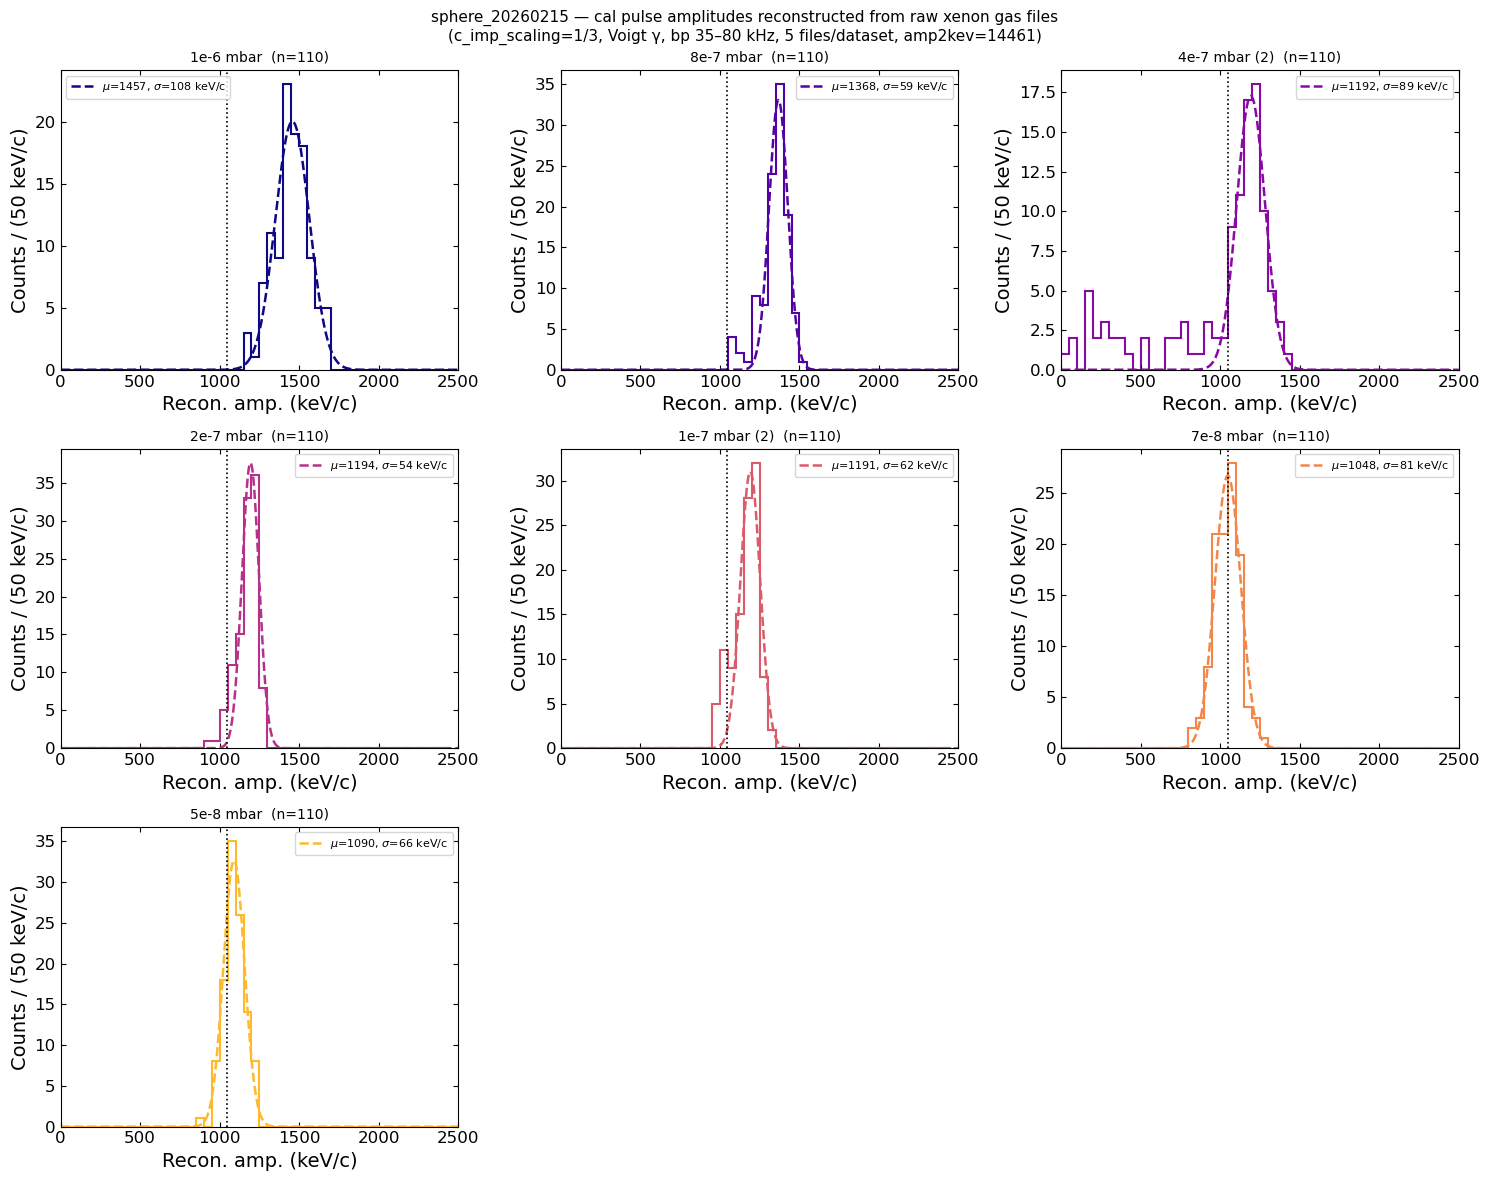

In [ ]:
plot_datasets = [(ds, lbl) for ds, lbl in xe_datasets
                 if ds not in ('20260219_p6e_4e-7mbar', '20260219_p6e_1e-7mbar')]

n_ds    = len(plot_datasets)
ncols   = 3
nrows   = (n_ds + ncols - 1) // ncols

bins_kev = np.arange(0, 2500, 50)
bc_kev   = 0.5 * (bins_kev[:-1] + bins_kev[1:])
colors   = plt.colormaps['plasma'](np.linspace(0, 0.85, n_ds))

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes_flat = axes.flatten()

for ax, (dataset, label), color in zip(axes_flat, plot_datasets, colors):
    arr = np.array(all_amps[dataset])

    hh, _ = np.histogram(arr, bins=bins_kev)
    ax.stairs(hh, edges=bins_kev, color=color, linewidth=1.5)

    if arr.size > 5:
        try:
            gp, _ = curve_fit(utils.gauss, bc_kev, hh,
                               p0=[hh.max(), np.mean(arr), np.std(arr)],
                               bounds=([0, 0, 0], np.inf), maxfev=10000)
            xx = np.linspace(0, 2500, 500)
            ax.plot(xx, utils.gauss(xx, *gp), '--', color=color, lw=1.8,
                    label=fr'$\mu$={gp[1]:.0f}, $\sigma$={gp[2]:.0f} keV/c')
            
            ax.legend(fontsize=8)
        except Exception as e:
            print(f'{label}: fit failed ({e})')

    ax.axvline(expected_kev, color='k', ls=':', lw=1.2)
    ax.set_title(f'{label}  (n={len(arr)})', fontsize=10)
    ax.set_xlabel('Recon. amp. (keV/c)')
    ax.set_xlim(0, 2500)
    ax.set_ylabel('Counts / (50 keV/c)')

for ax in axes_flat[n_ds:]:
    ax.set_visible(False)

fig.suptitle(f'{sphere} — cal pulse amplitudes reconstructed from raw xenon gas files\n'
             f'(c_imp_scaling=1/3, Voigt γ, bp {bandpass_lb//1000}–{bandpass_ub//1000} kHz, '
             f'{n_files} files/dataset, amp2kev={amp2kev_cal:.0f})',
             fontsize=11)
fig.tight_layout()
plt.show()

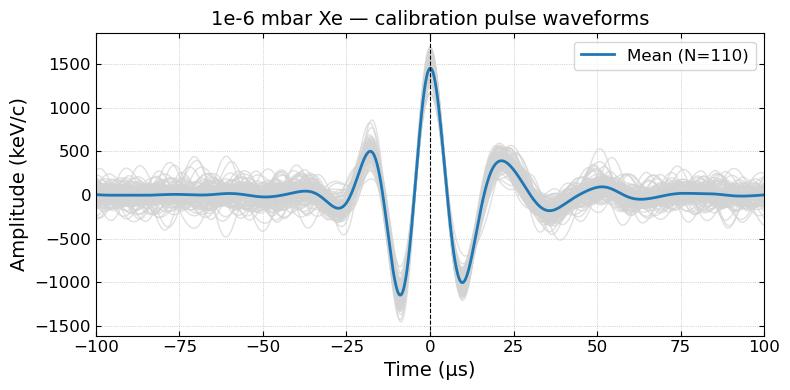

In [ ]:
# ── All 1e-6 mbar waveforms + average overlay ─────────────────────────────
ds_key = '20260219_p6e_1e-6mbar'
wavs   = np.array(all_waveforms[ds_key])   # shape: (N, 3000)

t_us = np.linspace(-waveform_half_len, waveform_half_len, wavs.shape[1]) / 5e6 * 1e6  # µs

fig, ax = plt.subplots(figsize=(8, 4))

for w in wavs:
    ax.plot(t_us, w, color='lightgray', alpha=0.7, linewidth=1)

avg = np.mean(wavs, axis=0)
ax.plot(t_us, avg, color='tab:blue', linewidth=2, label=f'Mean (N={len(wavs)})')

ax.axvline(0, color='k', linewidth=0.8, linestyle='--')
ax.set_xlim(-100, 100)

ax.set_xlabel('Time (µs)')
ax.set_ylabel('Amplitude (keV/c)')
ax.set_title('1e-6 mbar Xe — calibration pulse waveforms')
ax.legend()
ax.grid(which='both', ls=':', linewidth=0.5)
fig.tight_layout()


Pre-processing 5 files from 20260219_p6e_1e-6mbar
  file 0 (20260219_dfg_0.hdf5): f₀=47.936 kHz, γ=1.37 Hz, c_imp_voigt=3.296e-22
  file 1 (20260219_dfg_1.hdf5): f₀=47.947 kHz, γ=2.32 Hz, c_imp_voigt=3.166e-22
  file 2 (20260219_dfg_2.hdf5): f₀=47.937 kHz, γ=1.35 Hz, c_imp_voigt=4.027e-22
  file 3 (20260219_dfg_3.hdf5): f₀=47.952 kHz, γ=1.64 Hz, c_imp_voigt=3.056e-22
  file 4 (20260219_dfg_4.hdf5): f₀=47.940 kHz, γ=1.58 Hz, c_imp_voigt=3.384e-22
Skipping pulse too close to the beginning of the file
c_imp × 0.01: 110 pulses, amp2kev = 7362
Skipping pulse too close to the beginning of the file
c_imp × 0.02: 110 pulses, amp2kev = 7513
Skipping pulse too close to the beginning of the file
c_imp × 0.0333: 110 pulses, amp2kev = 7668
Skipping pulse too close to the beginning of the file
c_imp × 0.1: 110 pulses, amp2kev = 8396
Skipping pulse too close to the beginning of the file
c_imp × 0.333: 110 pulses, amp2kev = 9996
Skipping pulse too close to the beginning of the file
c_imp × 1: 110 puls

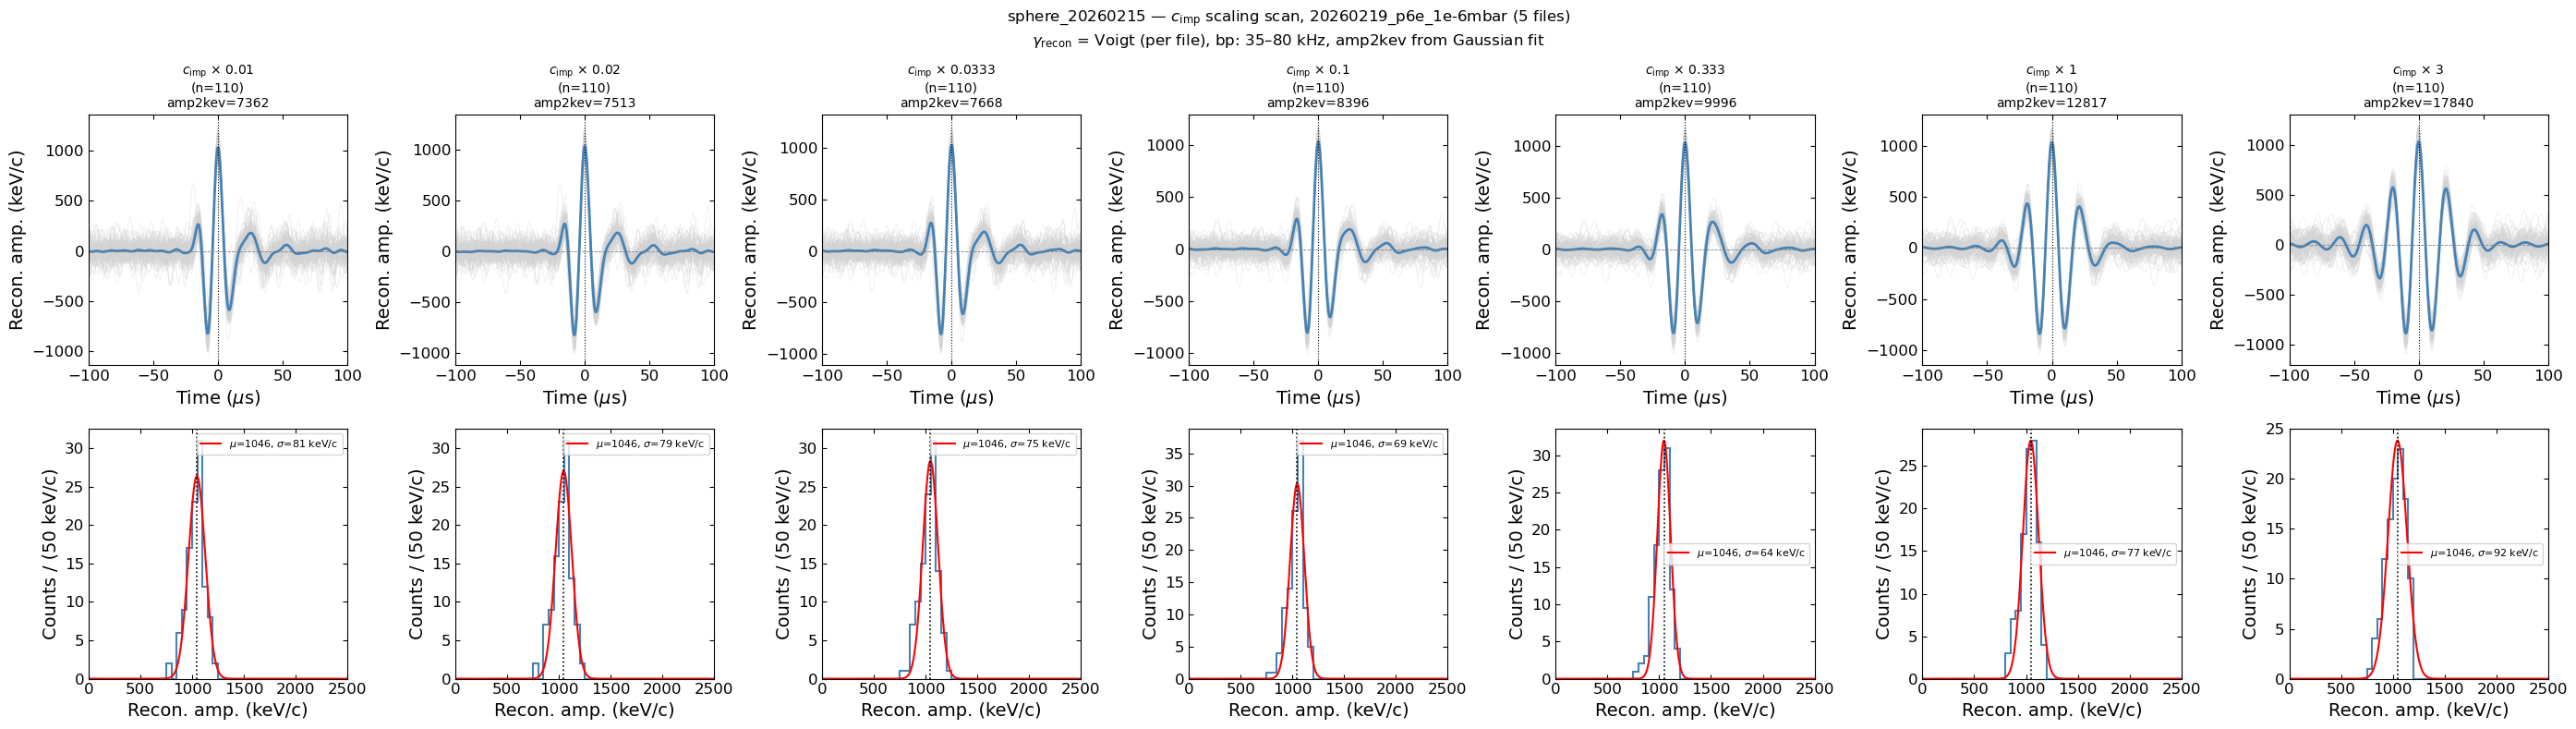

In [ ]:
# ── c_imp_scaling scan — 1e-6 mbar Xe, first 5 files ─────────────────────
# For each scaling value: averaged waveform overlay + amplitude histogram.
# amp2kev is derived from the Gaussian fit (expected_kev / fitted mean).
# gamma_recon uses per-file Voigt value.

_c_imp_scalings = [1/100, 1/50, 1/30, 1/10, 1/3, 1, 3]   # scaling factors to scan
_dataset        = '20260219_p6e_1e-6mbar'
_n_files        = 5
_gamma_recon_hz = None    # None → per-file Voigt gamma

# ── 1. Pre-process once (load, filter, Voigt fit) ─────────────────────────
# Load files sequentially by index (matching process_gas_data.py which uses
# f'{data_prefix}{i}.hdf5', NOT alphabetical glob which gives 0,1,10,11,12)
_raw_dir  = os.path.join(raw_base, _dataset)
_data_prefix = '20260219_dfg_'
print(f'Pre-processing {_n_files} files from {_dataset}')

_prep_xe = []
for _i in range(_n_files):
    _fp = os.path.join(_raw_dir, f'{_data_prefix}{_i}.hdf5')
    _dtt, _nn  = utils.load_timestreams(_fp, ['D', 'G'])
    _fs        = int(np.ceil(1 / _dtt))
    _zz, _dd   = _nn[0], _nn[1]

    _p_fit, _sv_imp, _ff, _ppz = utils.get_sv_imp(
        _fs, _zz, fit_band=(44000, 60000), noise_band=(110000, 120000),
        nperseg=2**19, p0=[5e-3, 48381*2*np.pi, 100*2*np.pi, 1*2*np.pi])
    _A, _omega0, _sigma_v, _gamma_v = _p_fit
    _gamma_damp  = _gamma_v * 2
    _c_imp_voigt = (np.pi / (_omega0**2 * _gamma_damp)) * _sv_imp / _A

    _zz_notched = utils.notch_filtered(_zz, _fs, f0=notch_freq, q=50)
    _zz_bp      = utils.bandpass_filtered(_zz_notched, _fs, bandpass_lb, bandpass_ub, order=lowpass_order)

    print(f'  file {_i} ({os.path.basename(_fp)}): f₀={_omega0/(2*np.pi)/1e3:.3f} kHz, '
          f'γ={_gamma_damp/(2*np.pi):.2f} Hz, c_imp_voigt={_c_imp_voigt:.3e}')
    _prep_xe.append((_dtt, _zz_bp, _dd, _omega0, _c_imp_voigt, _gamma_damp))

# ── 2. Scan ────────────────────────────────────────────────────────────────
_search_lo = analysis_window_length + pulse_length
_search_hi = _search_lo + search_window_length
_dtt_ref   = _prep_xe[0][0]
_tt_us     = (np.arange(2 * waveform_half_len) - waveform_half_len) * _dtt_ref * 1e6

n_cols = len(_c_imp_scalings)
fig, axes = plt.subplots(2, n_cols, figsize=(4 * n_cols, 8))

for col, _scaling in enumerate(_c_imp_scalings):
    _wavs_raw, _amps_raw = [], []
    for (_dtt, _zz_bp, _dd, _omega0, _c_imp_voigt, _gamma_damp) in _prep_xe:
        _c_imp       = _c_imp_voigt * _scaling
        _gamma_recon = _gamma_damp if _gamma_recon_hz is None else _gamma_recon_hz * 2 * np.pi

        for _idx in utils.get_pulse_idx(_dd, 0.5 * positive_pulse, positive_pulse):
            _, _, _amp_lp, _amp = utils.recon_pulse(
                _idx, _dtt, _zz_bp, _dd,
                c_imp=_c_imp, gamma_damping=_gamma_recon,
                analysis_window_length=analysis_window_length,
                prepulse_window_length=fit_window_length,
                search_window_length=search_window_length,
                pulse_length=pulse_length,
                lowpass_freq=bandpass_ub,
                lowpass_order=lowpass_order)
            if np.isnan(_amp):
                continue
            _amps_raw.append(_amp)
            _peak_i   = _search_lo + np.argmax(np.abs(_amp_lp[_search_lo:_search_hi]))
            _polarity = 1 if _amp_lp[_peak_i] > 0 else -1
            _lo, _hi  = _peak_i - waveform_half_len, _peak_i + waveform_half_len
            if _lo >= 0 and _hi <= _amp_lp.size:
                _wavs_raw.append(_polarity * _amp_lp[_lo:_hi])

    _amps_raw = np.asarray(_amps_raw)
    _wavs_raw = np.asarray(_wavs_raw)

    # Fit Gaussian in raw units → derive amp2kev
    _bins_raw = np.linspace(0, np.max(_amps_raw) * 1.3, 60)
    _bc_raw   = 0.5 * (_bins_raw[:-1] + _bins_raw[1:])
    _hh_raw, _ = np.histogram(_amps_raw, bins=_bins_raw)
    _a2k = None
    try:
        _gp_raw, _ = curve_fit(utils.gauss, _bc_raw, _hh_raw,
                                p0=[_hh_raw.max(), np.mean(_amps_raw), np.std(_amps_raw)],
                                bounds=([0, 0, 0], np.inf), maxfev=10000)
        _a2k = expected_kev / _gp_raw[1]
    except Exception as _e:
        print(f'  c_imp × {_scaling:.3g}: Gaussian fit failed ({_e})')

    _a2k_plot = _a2k if _a2k is not None else amp2kev_cal
    print(f'c_imp × {_scaling:.3g}: {len(_amps_raw)} pulses, amp2kev = {_a2k_plot:.0f}')

    # Convert to keV/c for plotting
    _amps_kev = _amps_raw * _a2k_plot
    _wavs_kev = _wavs_raw * _a2k_plot

    # Waveform overlay + mean
    ax_w = axes[0, col]
    for _w in _wavs_kev:
        ax_w.plot(_tt_us, _w, color='lightgray', lw=0.6, alpha=0.4)
    if len(_wavs_kev):
        ax_w.plot(_tt_us, _wavs_kev.mean(axis=0), color='steelblue', lw=2)
    ax_w.axhline(0, color='gray', ls='--', lw=0.6)
    ax_w.axvline(0, color='k',    ls=':',  lw=0.8)
    ax_w.set_xlim(-100, 100)
    ax_w.set_xlabel(r'Time ($\mu$s)')
    ax_w.set_ylabel('Recon. amp. (keV/c)')
    _title = fr'$c_\mathrm{{imp}}$ × {_scaling:.3g}' + f'\n(n={len(_wavs_kev)})'
    if _a2k is not None:
        _title += f'\namp2kev={_a2k:.0f}'
    ax_w.set_title(_title, fontsize=10)

    # Amplitude histogram + Gaussian fit (in keV/c)
    ax_h = axes[1, col]
    _bins_kev = np.arange(0, 2500, 50)
    _bc_kev   = 0.5 * (_bins_kev[:-1] + _bins_kev[1:])
    _hh_kev, _ = np.histogram(_amps_kev, bins=_bins_kev)
    ax_h.stairs(_hh_kev, edges=_bins_kev, color='steelblue', lw=1.5)
    if _a2k is not None:
        _xx = np.linspace(0, 2500, 500)
        _dbin_raw = (_bins_raw[-1] - _bins_raw[0]) / (len(_bins_raw) - 1)
        _dbin_kev = 50 / _a2k_plot
        ax_h.plot(_xx, utils.gauss(_xx / _a2k_plot, *_gp_raw) * (_dbin_kev / _dbin_raw),
                  'r-', lw=1.5,
                  label=fr'$\mu$={_gp_raw[1]*_a2k:.0f}, $\sigma$={_gp_raw[2]*_a2k:.0f} keV/c')
        ax_h.legend(fontsize=8)
    ax_h.axvline(expected_kev, color='k', ls=':', lw=1.2)
    ax_h.set_xlim(0, 2500)
    ax_h.set_xlabel('Recon. amp. (keV/c)')
    ax_h.set_ylabel('Counts / (50 keV/c)')

_gamma_label = (f'{_gamma_recon_hz} Hz' if _gamma_recon_hz is not None else 'Voigt (per file)')
fig.suptitle(
    fr'{sphere} — $c_\mathrm{{imp}}$ scaling scan, {_dataset} ({_n_files} files)' + '\n'
    + fr'$\gamma_\mathrm{{recon}}$ = {_gamma_label}, '
    + f'bp: {bandpass_lb//1000}–{bandpass_ub//1000} kHz, amp2kev from Gaussian fit',
    fontsize=12)
fig.tight_layout()
plt.show()

## Look through the processed calibration pulses

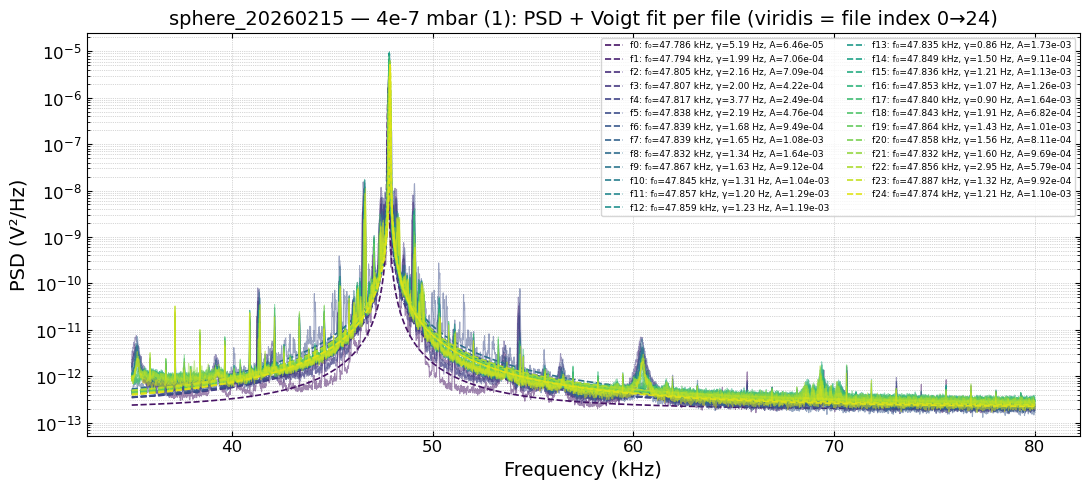

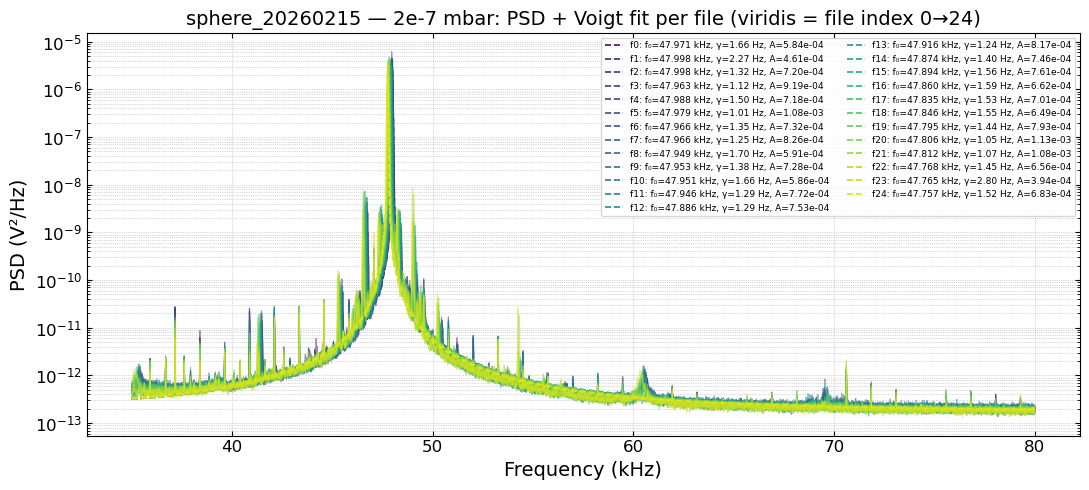

In [ ]:
# ── PSD + Voigt+sv_imp for all files in a dataset (from cal_processed.hdf5) ──
# Useful for diagnosing bad Voigt fits (e.g. 4e-7mbar_1 files 0–5)

diag_datasets = [
    ('20260219_p6e_4e-7mbar_1', 'xenon_data', '4e-7 mbar (1)'),
    ('20260219_p6e_2e-7mbar',   'xenon_data', '2e-7 mbar'),   # reference
]
freq_lim = (35, 80)   # kHz

for dataset, data_type, title in diag_datasets:
    cal_path = os.path.join(gas_dir, data_type, dataset, f'{dataset}_cal_processed.hdf5')
    if not os.path.exists(cal_path):
        print(f'Missing: {cal_path}')
        continue

    with h5py.File(cal_path, 'r') as f:
        g       = f['data_processed']
        ffz     = g['ffz'][:]
        sv_zs   = g['sv_z'][:]        # (n_files, n_freq)
        vps     = g['voigt_params'][:] # (n_files, 4)
        sv_imps = g['sv_imp'][:]       # (n_files,)

    n_files = len(vps)
    colors  = plt.colormaps['viridis'](np.linspace(0.05, 0.95, n_files))
    idx_f   = (ffz >= freq_lim[0] * 1e3) & (ffz <= freq_lim[1] * 1e3)

    fig, ax = plt.subplots(figsize=(11, 5))

    for i, (sv_z, vp, sv_imp, color) in enumerate(zip(sv_zs, vps, sv_imps, colors)):
        A, omega0, sigma, gamma_v = vp
        f0_hz = omega0 / (2 * np.pi)
        gamma_d_hz = gamma_v * 2 / (2 * np.pi)

        ax.semilogy(ffz[idx_f] / 1e3, sv_z[idx_f],
                    color=color, lw=0.8, alpha=0.5)
        ax.semilogy(ffz[idx_f] / 1e3,
                    utils.voigt(ffz[idx_f] * 2 * np.pi, A, omega0, sigma, gamma_v) + sv_imp,
                    '--', color=color, lw=1.2,
                    label=f'f{i}: f₀={f0_hz/1e3:.3f} kHz, γ={gamma_d_hz:.2f} Hz, A={A:.2e}')

    ax.set_xlabel('Frequency (kHz)')
    ax.set_ylabel('PSD (V²/Hz)')
    ax.set_title(f'{sphere} — {title}: PSD + Voigt fit per file (viridis = file index 0→{n_files-1})')
    ax.legend(fontsize=6.5, loc='upper right', ncol=2)
    ax.grid(which='both', ls=':', lw=0.5)
    fig.tight_layout()
    plt.show()

In [38]:
# ── Helper functions for cal_processed.hdf5 loading, fitting, cuts, saving ──

def load_cal_processed(cal_path):
    """Load per-pulse arrays from a _cal_processed.hdf5 file."""
    with h5py.File(cal_path, 'r') as f:
        g = f['data_processed']
        return dict(
            amplitude     = g['amplitude'][:],
            waveform      = g['waveform'][:],
            noise_level   = g['noise_level_amp'][:],
            driven_power  = g['driven_power'][:],
            f_res         = g['f_res'][:],
            c_imp_scaling = float(g.attrs['c_imp_scaling']),
        )

def fit_gaussian_amps(amps, expected_kev, n_bins=60):
    """Fit Gaussian to amplitude histogram. Returns (bins, hh, gp, a2k)."""
    bins = np.linspace(0, np.max(amps) * 1.3, n_bins + 1)
    bc   = 0.5 * (bins[:-1] + bins[1:])
    hh, _ = np.histogram(amps, bins=bins)
    gp, a2k = None, None
    try:
        gp, _ = curve_fit(utils.gauss, bc, hh,
                          p0=[hh.max(), np.mean(amps), np.std(amps)],
                          bounds=([0, 0, 0], np.inf), maxfev=10000)
        a2k = expected_kev / gp[1]
    except Exception as e:
        print(f'  Gaussian fit failed: {e}')
    return bins, hh, gp, a2k

def compute_norm_drive(drv_power, f_res_arr, drive_freq, ref_freq):
    """Normalise driven power to a reference resonant frequency."""
    return drv_power * (f_res_arr**2 - drive_freq**2)**2 / (ref_freq**2 - drive_freq**2)**2

def apply_quality_cuts(noise_kev, norm_drive, noise_cut_kev, drive_cut):
    """Return boolean mask selecting pulses that pass quality cuts."""
    return (noise_kev < noise_cut_kev) & (norm_drive > drive_cut)

def save_cal_summary_hdf5(out_path, entries, sphere, noise_cut_kev, drive_cut, expected_kev):
    """Save per-dataset calibration info to an HDF5 summary file.

    entries: list of dicts with keys:
        dataset, label, amps_raw, wavs_raw, a2k, gp, c_imp_scaling
    """
    with h5py.File(out_path, 'w') as fout:
        fout.attrs['noise_cut_kev'] = noise_cut_kev
        fout.attrs['drive_cut']     = drive_cut
        fout.attrs['expected_kev']  = expected_kev
        fout.attrs['sphere']        = sphere
        for e in entries:
            if e['a2k'] is None:
                print(f"  Skipping {e['dataset']} — Gaussian fit failed, no amp2kev")
                continue
            mean_wav_raw = e['wavs_raw'].mean(axis=0)
            norm_wav     = mean_wav_raw / np.max(np.abs(mean_wav_raw))
            g = fout.create_group(e['dataset'])
            g.attrs['label']         = e['label']
            g.attrs['c_imp_scaling'] = e['c_imp_scaling']
            g.attrs['n_pulses']      = len(e['amps_raw'])
            g.create_dataset('amplitude',     data=e['amps_raw'],  dtype=np.float64)
            g.create_dataset('amp2kev',       data=np.float64(e['a2k']))
            g.create_dataset('mean_waveform', data=mean_wav_raw,   dtype=np.float64)
            g.create_dataset('norm_waveform', data=norm_wav,       dtype=np.float64)
            sigma_str = f", σ={e['gp'][2]*e['a2k']:.0f} keV/c" if e['gp'] is not None else ''
            print(f"  {e['dataset']}: {len(e['amps_raw'])} pulses, amp2kev={e['a2k']:.0f}{sigma_str} → saved")
    print(f'\nWritten: {out_path}')

1e-6 mbar: 550 pulses, c_imp=0.2, amp2kev=9468, μ=1046, σ=71 keV/c
8e-7 mbar: 550 pulses, c_imp=0.2, amp2kev=9943, μ=1046, σ=52 keV/c
4e-7 mbar: 550 pulses, c_imp=0.2, amp2kev=11194, μ=1046, σ=83 keV/c
2e-7 mbar: 551 pulses, c_imp=0.3333, amp2kev=12692, μ=1046, σ=61 keV/c
1e-7 mbar: 551 pulses, c_imp=0.2, amp2kev=11589, μ=1046, σ=73 keV/c
7e-8 mbar: 552 pulses, c_imp=0.2, amp2kev=12262, μ=1046, σ=76 keV/c
5e-8 mbar: 550 pulses, c_imp=0.1, amp2kev=10410, μ=1046, σ=63 keV/c


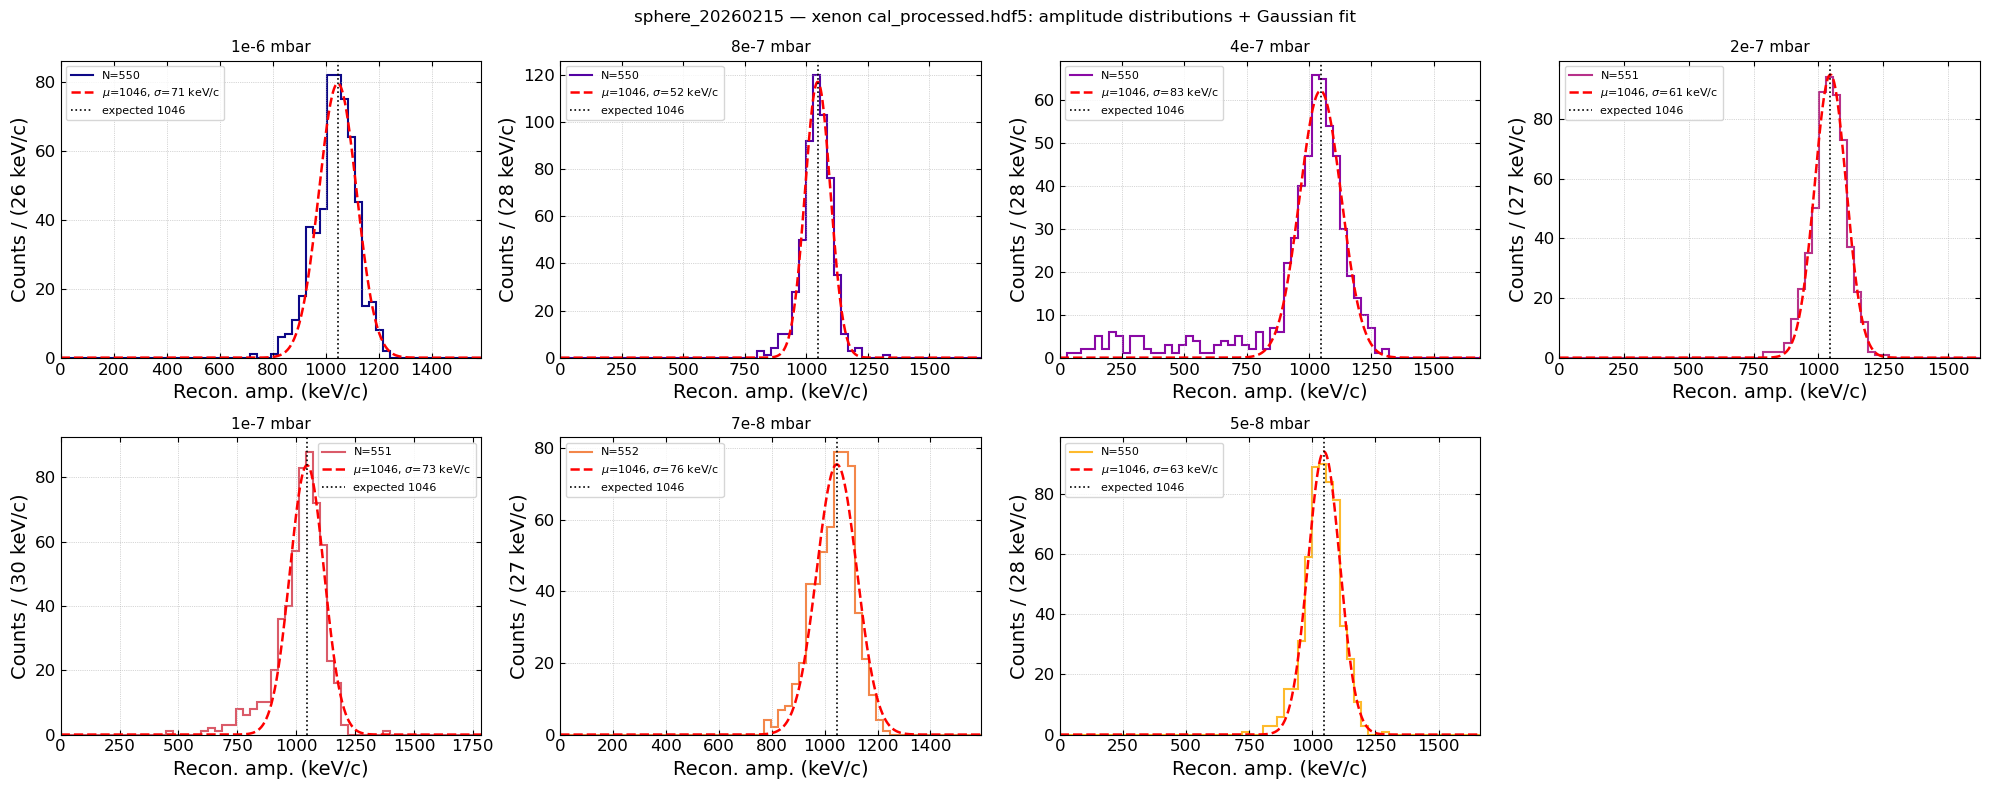

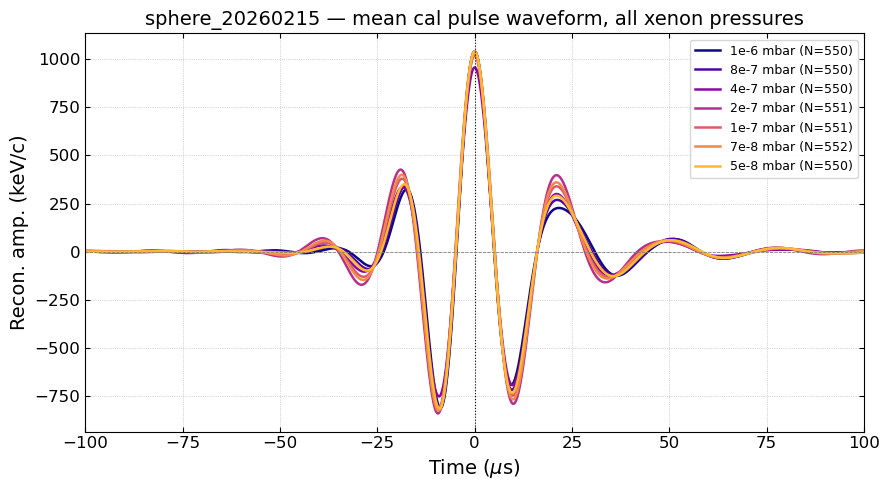

In [39]:
# ── Load cal_processed.hdf5 for all xenon datasets ────────────────────────

cal_datasets = [
    ('20260219_p6e_1e-6mbar',   '1e-6 mbar'),
    ('20260219_p6e_8e-7mbar',   '8e-7 mbar'),
    ('20260219_p6e_4e-7mbar_1', '4e-7 mbar'),
    ('20260219_p6e_2e-7mbar',   '2e-7 mbar'),
    ('20260219_p6e_1e-7mbar_1', '1e-7 mbar'),
    ('20260219_p6e_7e-8mbar',   '7e-8 mbar'),
    ('20260219_p6e_5e-8mbar',   '5e-8 mbar'),
]
xe_colors = plt.colormaps['plasma'](np.linspace(0, 0.85, len(cal_datasets)))
dtt_ref   = 200e-9   # 5 MHz sampling

xe_loaded = []
for (dataset, label), color in zip(cal_datasets, xe_colors):
    cal_path = os.path.join(gas_dir, 'xenon_data', dataset, f'{dataset}_cal_processed.hdf5')
    if not os.path.exists(cal_path):
        print(f'Missing: {cal_path}')
        continue
    data = load_cal_processed(cal_path)
    bins_raw, hh, gp, a2k = fit_gaussian_amps(data['amplitude'], expected_kev)
    a2k_plot = a2k if a2k is not None else amp2kev_cal
    print(f'{label}: {len(data["amplitude"])} pulses, c_imp={data["c_imp_scaling"]:.4g}'
          + (f', amp2kev={a2k:.0f}, μ={gp[1]*a2k:.0f}, σ={gp[2]*a2k:.0f} keV/c' if gp is not None else ''))
    xe_loaded.append(dict(dataset=dataset, label=label, color=color,
                          data=data, bins_raw=bins_raw, hh=hh, gp=gp, a2k=a2k))

# ── Figure 1: per-dataset amplitude histograms ────────────────────────────
n_ds  = len(xe_loaded)
ncols = 4
nrows = (n_ds + ncols - 1) // ncols

fig1, axes1 = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes1_flat  = np.array(axes1).flatten()

for ax, e in zip(axes1_flat, xe_loaded):
    a2k_plot = e['a2k'] if e['a2k'] is not None else amp2kev_cal
    bins_kev = e['bins_raw'] * a2k_plot
    ax.stairs(e['hh'], edges=bins_kev, color=e['color'], lw=1.5,
              label=f'N={len(e["data"]["amplitude"])}')
    if e['gp'] is not None:
        xx = np.linspace(0, bins_kev[-1], 500)
        ax.plot(xx, utils.gauss(xx / a2k_plot, *e['gp']), 'r--', lw=1.8,
                label=fr'$\mu$={e["gp"][1]*a2k_plot:.0f}, $\sigma$={e["gp"][2]*a2k_plot:.0f} keV/c')
    ax.axvline(expected_kev, color='k', ls=':', lw=1.2, label=f'expected {expected_kev}')
    ax.set_title(e['label'], fontsize=11)
    ax.set_xlabel('Recon. amp. (keV/c)')
    ax.set_ylabel(f'Counts / ({bins_kev[1]-bins_kev[0]:.0f} keV/c)')
    ax.set_xlim(0, bins_kev[-1])
    ax.legend(fontsize=8)
    ax.grid(which='both', ls=':', lw=0.5)

for ax in axes1_flat[n_ds:]:
    ax.set_visible(False)

fig1.suptitle(f'{sphere} — xenon cal_processed.hdf5: amplitude distributions + Gaussian fit', fontsize=12)
fig1.tight_layout()
plt.show()

# ── Figure 2: mean waveform per dataset ───────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(9, 5))
for e in xe_loaded:
    a2k_plot = e['a2k'] if e['a2k'] is not None else amp2kev_cal
    wavs_kev = e['data']['waveform'] * a2k_plot
    whl   = wavs_kev.shape[1] // 2
    tt_us = (np.arange(wavs_kev.shape[1]) - whl) * dtt_ref * 1e6
    ax2.plot(tt_us, wavs_kev.mean(axis=0), color=e['color'], lw=1.8,
             label=f'{e["label"]} (N={len(wavs_kev)})')

ax2.axvline(0, color='k', ls=':', lw=0.8)
ax2.axhline(0, color='gray', ls='--', lw=0.6)
ax2.set_xlim(-100, 100)
ax2.set_xlabel(r'Time ($\mu$s)')
ax2.set_ylabel('Recon. amp. (keV/c)')
ax2.set_title(f'{sphere} — mean cal pulse waveform, all xenon pressures')
ax2.legend(fontsize=9)
ax2.grid(which='both', ls=':', lw=0.5)
fig2.tight_layout()
plt.show()

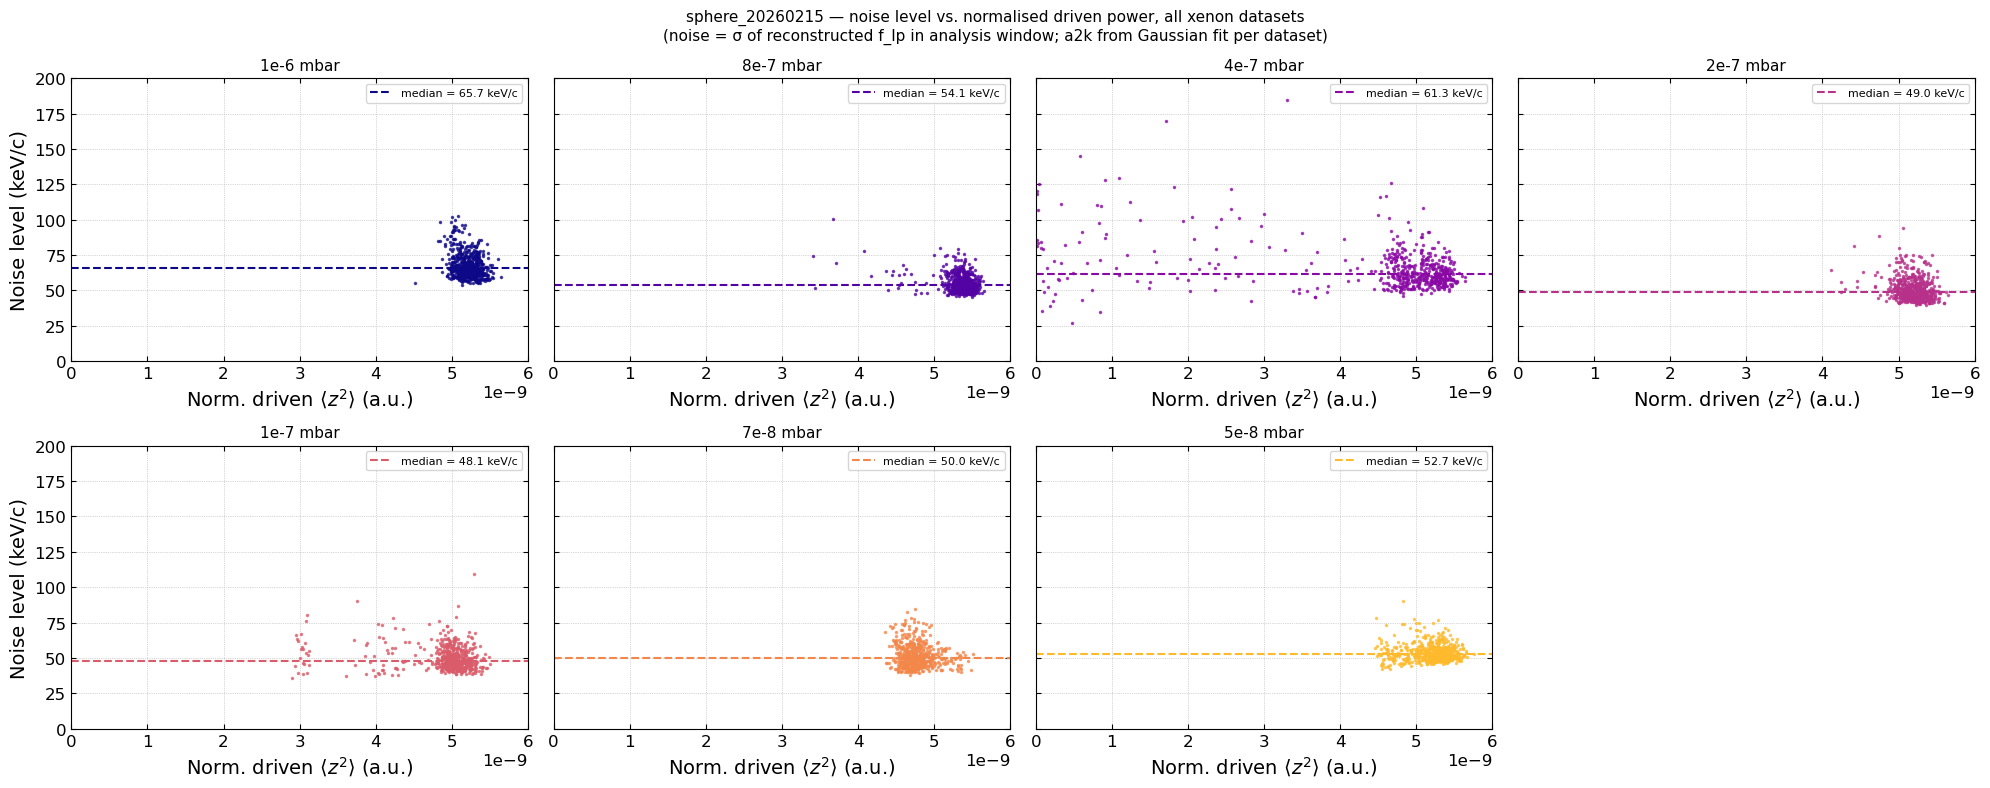

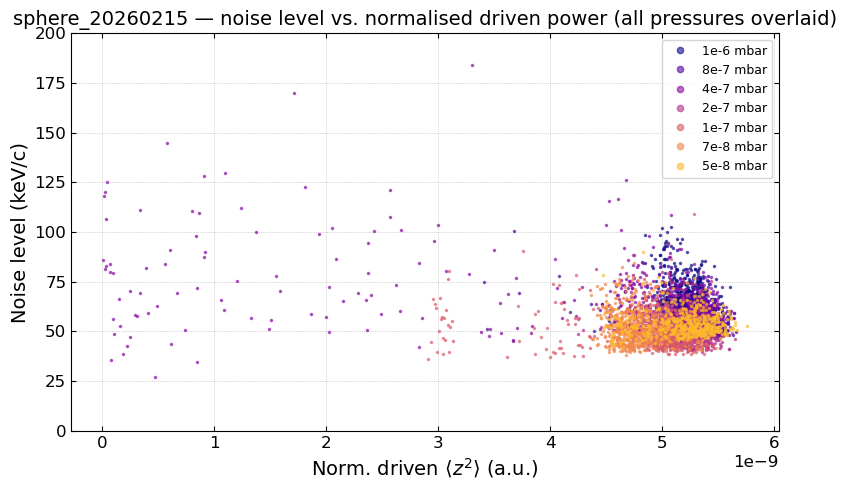

In [40]:
# ── Noise level vs. normalised driven tone power — all xenon datasets ─────

drive_freq = 137000   # Hz — notch / drive tone
ref_freq   = 48500    # Hz — reference resonant frequency for normalisation

# Compute noise_kev and norm_drive and attach to each xe_loaded entry
for e in xe_loaded:
    a2k_plot = e['a2k'] if e['a2k'] is not None else amp2kev_cal
    e['noise_kev']  = e['data']['noise_level'] * a2k_plot
    e['norm_drive'] = compute_norm_drive(e['data']['driven_power'], e['data']['f_res'],
                                         drive_freq, ref_freq)

# ── Figure 1: one panel per dataset ───────────────────────────────────────
n_ds  = len(xe_loaded)
ncols = 4
nrows = (n_ds + ncols - 1) // ncols

fig1, axes1 = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), sharey=True)
axes1_flat  = np.array(axes1).flatten()

for ax, e in zip(axes1_flat, xe_loaded):
    ax.plot(e['norm_drive'], e['noise_kev'], '.', color=e['color'], markersize=3, alpha=0.7)
    med = np.median(e['noise_kev'])
    ax.axhline(med, color=e['color'], lw=1.5, ls='--', label=f'median = {med:.1f} keV/c')
    ax.set_title(e['label'], fontsize=11)
    ax.set_xlabel(r'Norm. driven $\langle z^2 \rangle$ (a.u.)')
    ax.set_ylim(0, 200)
    ax.set_xlim(0, 6e-9)
    ax.legend(fontsize=8)
    ax.grid(which='both', ls=':', lw=0.5)

for ax in axes1_flat[n_ds:]:
    ax.set_visible(False)

axes1_flat[0].set_ylabel('Noise level (keV/c)')
if nrows > 1:
    axes1_flat[ncols].set_ylabel('Noise level (keV/c)')

fig1.suptitle(f'{sphere} — noise level vs. normalised driven power, all xenon datasets\n'
              f'(noise = σ of reconstructed f_lp in analysis window; a2k from Gaussian fit per dataset)',
              fontsize=11)
fig1.tight_layout()
plt.show()

# ── Figure 2: all datasets overlaid ───────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(8, 5))
for e in xe_loaded:
    ax2.plot(e['norm_drive'], e['noise_kev'], '.', color=e['color'],
             markersize=3, alpha=0.6, label=e['label'])

ax2.set_xlabel(r'Norm. driven $\langle z^2 \rangle$ (a.u.)')
ax2.set_ylabel('Noise level (keV/c)')
ax2.set_ylim(0, 200)
ax2.legend(fontsize=9, markerscale=3)
ax2.set_title(f'{sphere} — noise level vs. normalised driven power (all pressures overlaid)')
ax2.grid(which='both', ls=':', lw=0.5)
fig2.tight_layout()
plt.show()

1e-6 mbar: 548/550 pulses pass cuts (99.6%)
  amp2kev = 9472  (was 9468),  μ = 1046,  σ = 71 keV/c
8e-7 mbar: 540/550 pulses pass cuts (98.2%)
  amp2kev = 9936  (was 9943),  μ = 1046,  σ = 51 keV/c
4e-7 mbar: 438/550 pulses pass cuts (79.6%)
  amp2kev = 11162  (was 11194),  μ = 1046,  σ = 79 keV/c
2e-7 mbar: 544/551 pulses pass cuts (98.7%)
  amp2kev = 12689  (was 12692),  μ = 1046,  σ = 61 keV/c
1e-7 mbar: 486/551 pulses pass cuts (88.2%)
  amp2kev = 11538  (was 11589),  μ = 1046,  σ = 66 keV/c
7e-8 mbar: 530/552 pulses pass cuts (96.0%)
  amp2kev = 12261  (was 12262),  μ = 1046,  σ = 75 keV/c
5e-8 mbar: 545/550 pulses pass cuts (99.1%)
  amp2kev = 10411  (was 10410),  μ = 1046,  σ = 63 keV/c


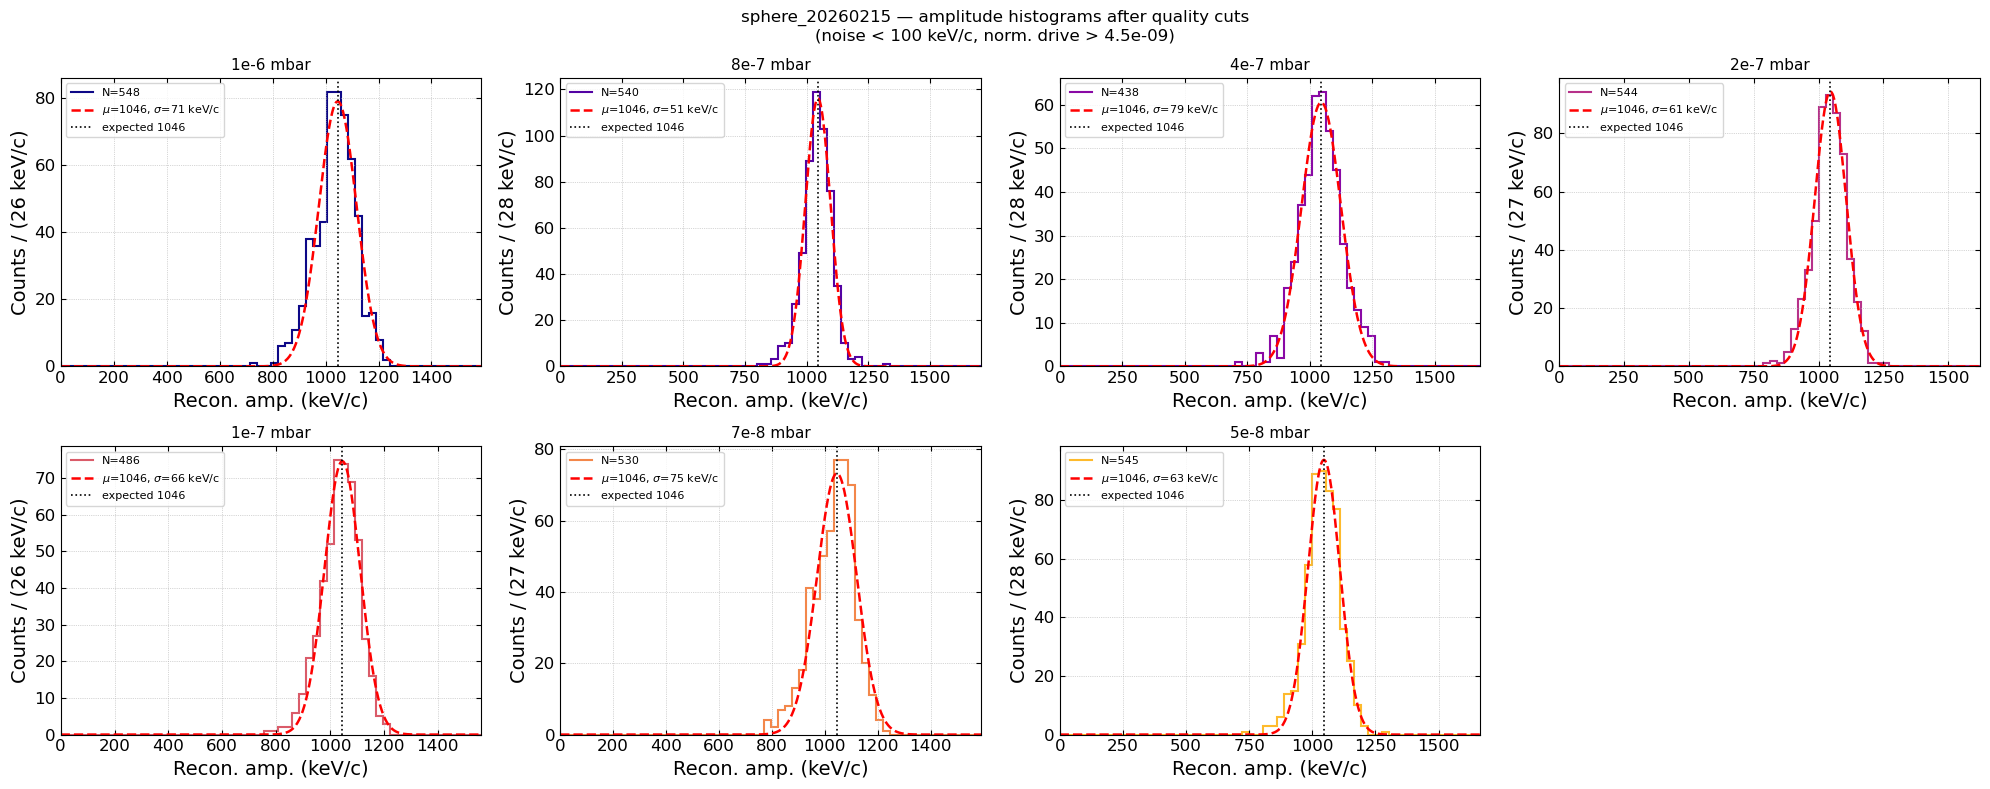

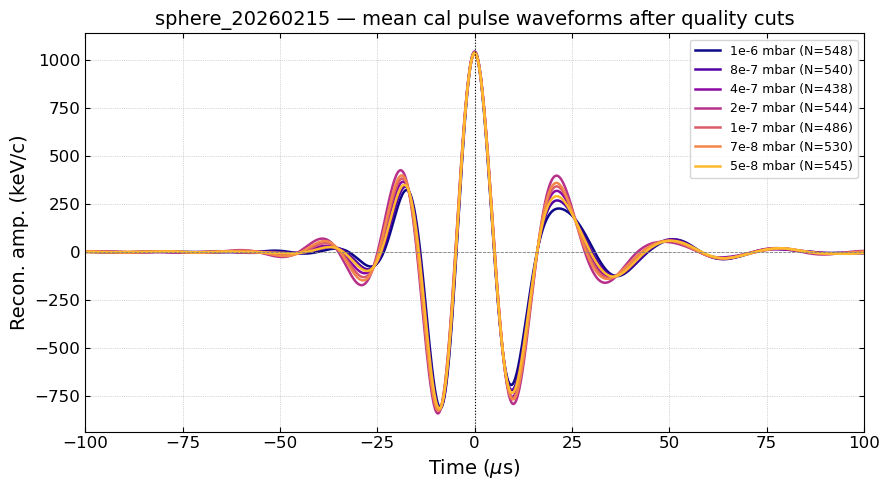

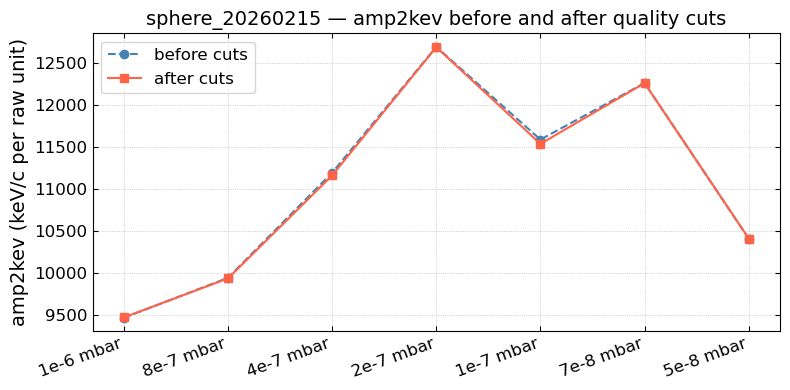

In [41]:
# ── Quality cuts: noise < 100 keV/c  AND  norm. driven power > 4.5e-9 ────

noise_cut_kev = 100
drive_cut     = 4.5e-9

xe_loaded_cut = []
for e in xe_loaded:
    mask = apply_quality_cuts(e['noise_kev'], e['norm_drive'], noise_cut_kev, drive_cut)
    n_before, n_after = len(e['data']['amplitude']), int(mask.sum())
    print(f'{e["label"]}: {n_after}/{n_before} pulses pass cuts ({100*n_after/n_before:.1f}%)')

    amps_sel = e['data']['amplitude'][mask]
    wavs_sel = e['data']['waveform'][mask]

    bins_cut, hh_cut, gp_cut, a2k_cut = fit_gaussian_amps(amps_sel, expected_kev)
    a2k_final = a2k_cut if a2k_cut is not None else (e['a2k'] if e['a2k'] is not None else amp2kev_cal)
    if gp_cut is not None:
        a2k_before = e['a2k'] if e['a2k'] is not None else amp2kev_cal
        print(f'  amp2kev = {a2k_cut:.0f}  (was {a2k_before:.0f}),  '
              f'μ = {gp_cut[1]*a2k_cut:.0f},  σ = {gp_cut[2]*a2k_cut:.0f} keV/c')

    xe_loaded_cut.append(dict(
        dataset=e['dataset'], label=e['label'], color=e['color'],
        amps_raw=amps_sel, wavs_raw=wavs_sel,
        amps_kev=amps_sel * a2k_final, wavs_kev=wavs_sel * a2k_final,
        bins_cut=bins_cut, hh_cut=hh_cut, gp=gp_cut, a2k=a2k_cut,
        c_imp_scaling=e['data']['c_imp_scaling'],
    ))

# ── Figure 1: amplitude histograms after cuts ─────────────────────────────
n_ds  = len(xe_loaded_cut)
ncols = 4
nrows = (n_ds + ncols - 1) // ncols

fig1, axes1 = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes1_flat  = np.array(axes1).flatten()

for ax, e in zip(axes1_flat, xe_loaded_cut):
    a2k_plot = e['a2k'] if e['a2k'] is not None else amp2kev_cal
    bins_kev = e['bins_cut'] * a2k_plot
    ax.stairs(e['hh_cut'], edges=bins_kev, color=e['color'], lw=1.5, label=f'N={len(e["amps_kev"])}')
    if e['gp'] is not None:
        xx = np.linspace(0, bins_kev[-1], 500)
        ax.plot(xx, utils.gauss(xx / a2k_plot, *e['gp']), 'r--', lw=1.8,
                label=fr'$\mu$={e["gp"][1]*a2k_plot:.0f}, $\sigma$={e["gp"][2]*a2k_plot:.0f} keV/c')
    ax.axvline(expected_kev, color='k', ls=':', lw=1.2, label=f'expected {expected_kev}')
    ax.set_title(e['label'], fontsize=11)
    ax.set_xlabel('Recon. amp. (keV/c)')
    ax.set_ylabel(f'Counts / ({bins_kev[1]-bins_kev[0]:.0f} keV/c)')
    ax.set_xlim(0, bins_kev[-1])
    ax.legend(fontsize=8)
    ax.grid(which='both', ls=':', lw=0.5)

for ax in axes1_flat[n_ds:]:
    ax.set_visible(False)

fig1.suptitle(f'{sphere} — amplitude histograms after quality cuts\n'
              f'(noise < {noise_cut_kev} keV/c, norm. drive > {drive_cut:.1e})', fontsize=12)
fig1.tight_layout()
plt.show()

# ── Figure 2: mean waveforms after cuts ───────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(9, 5))
for e in xe_loaded_cut:
    whl   = e['wavs_kev'].shape[1] // 2
    tt_us = (np.arange(e['wavs_kev'].shape[1]) - whl) * dtt_ref * 1e6
    ax2.plot(tt_us, e['wavs_kev'].mean(axis=0), color=e['color'], lw=1.8,
             label=f'{e["label"]} (N={len(e["amps_kev"])})')

ax2.axvline(0, color='k', ls=':', lw=0.8)
ax2.axhline(0, color='gray', ls='--', lw=0.6)
ax2.set_xlim(-100, 100)
ax2.set_xlabel(r'Time ($\mu$s)')
ax2.set_ylabel('Recon. amp. (keV/c)')
ax2.set_title(f'{sphere} — mean cal pulse waveforms after quality cuts')
ax2.legend(fontsize=9)
ax2.grid(which='both', ls=':', lw=0.5)
fig2.tight_layout()
plt.show()

# ── Figure 3: amp2kev before vs. after cuts ───────────────────────────────
a2k_before = [e['a2k'] if e['a2k'] is not None else amp2kev_cal for e in xe_loaded]
a2k_after  = [e['a2k'] if e['a2k'] is not None else amp2kev_cal for e in xe_loaded_cut]
labels_fit = [e['label'] for e in xe_loaded_cut]

fig3, ax3 = plt.subplots(figsize=(8, 4))
xx3 = np.arange(len(labels_fit))
ax3.plot(xx3, a2k_before[:len(xx3)], 'o--', color='steelblue', label='before cuts')
ax3.plot(xx3, a2k_after,             's-',  color='tomato',    label='after cuts')
ax3.set_xticks(xx3)
ax3.set_xticklabels(labels_fit, rotation=20, ha='right')
ax3.set_ylabel('amp2kev (keV/c per raw unit)')
ax3.set_title(f'{sphere} — amp2kev before and after quality cuts')
ax3.legend()
ax3.grid(which='both', ls=':', lw=0.5)
fig3.tight_layout()
plt.show()

In [ ]:
# ── Save selected amplitudes, amp2kev, and mean waveforms to HDF5 ─────────
out_path = os.path.join(gas_dir, 'xenon_data', f'{sphere}_xenon_cal_summary.hdf5')
save_cal_summary_hdf5(out_path, xe_loaded_cut, sphere, noise_cut_kev, drive_cut, expected_kev)

## Background datasets — calibration pulse amplitudes and noise

4e-8 mbar: 552 pulses, c_imp=0.2, amp2kev=12822, μ=1046, σ=74 keV/c
3e-8 mbar (Xe valve closed): 551 pulses, c_imp=0.1, amp2kev=10643, μ=1046, σ=77 keV/c
3e-8 mbar (Kr valve closed): 550 pulses, c_imp=0.2, amp2kev=12955, μ=1046, σ=61 keV/c
3e-8 mbar (SF6 valve closed): 550 pulses, c_imp=0.2, amp2kev=12454, μ=1046, σ=80 keV/c


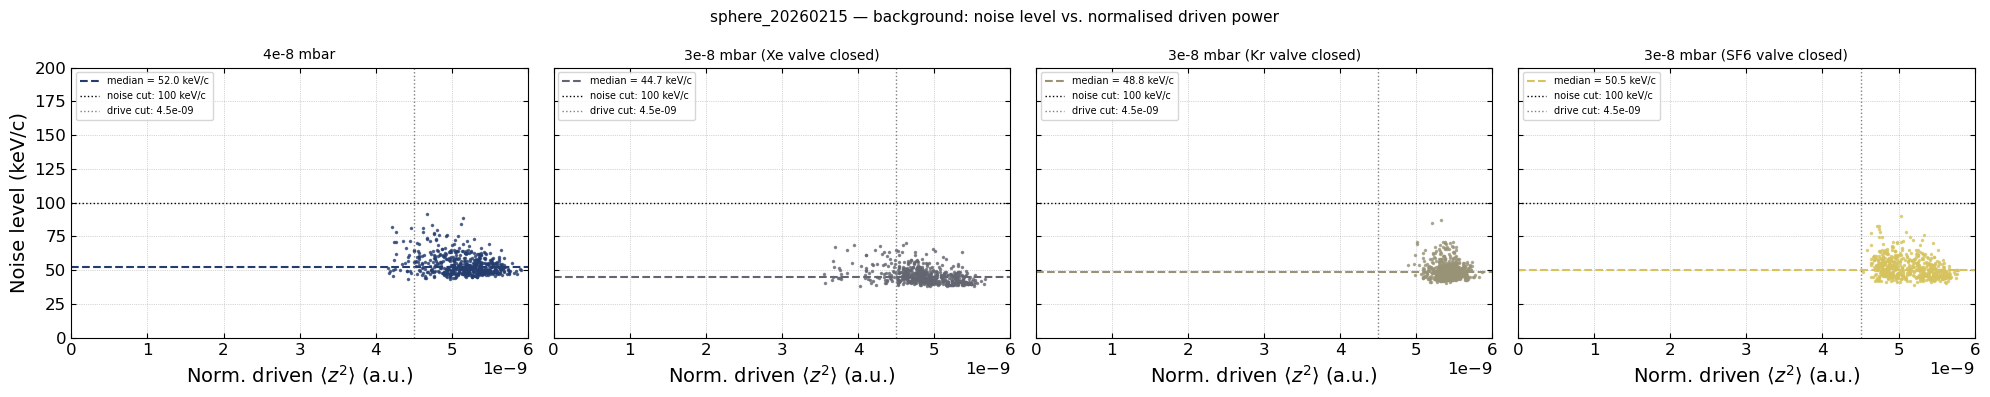

In [54]:
# ── Load background cal_processed.hdf5 and plot noise vs. driven power ────

bg_datasets = [
    ('20260219_p6e_4e-8mbar',               '4e-8 mbar'),
    ('20260219_p6e_3e-8mbar_xevalveclosed', '3e-8 mbar (Xe valve closed)'),
    ('20260219_p6e_3e-8mbar_krvalveclosed', '3e-8 mbar (Kr valve closed)'),
    ('20260219_p6e_3e-8mbar_sf6valveclosed','3e-8 mbar (SF6 valve closed)'),
]
bg_colors = plt.colormaps['cividis'](np.linspace(0.15, 0.85, len(bg_datasets)))

bg_loaded = []
for (dataset, label), color in zip(bg_datasets, bg_colors):
    cal_path = os.path.join(gas_dir, 'background_data', dataset, f'{dataset}_cal_processed.hdf5')
    if not os.path.exists(cal_path):
        print(f'Missing: {cal_path}')
        continue

    data = load_cal_processed(cal_path)
    bins_raw, hh, gp, a2k = fit_gaussian_amps(data['amplitude'], expected_kev)
    a2k_plot   = a2k if a2k is not None else amp2kev_cal
    noise_kev  = data['noise_level'] * a2k_plot
    norm_drive = compute_norm_drive(data['driven_power'], data['f_res'], drive_freq, ref_freq)

    print(f'{label}: {len(data["amplitude"])} pulses, c_imp={data["c_imp_scaling"]:.4g}'
          + (f', amp2kev={a2k:.0f}, μ={gp[1]*a2k:.0f}, σ={gp[2]*a2k:.0f} keV/c' if gp is not None else ''))
    bg_loaded.append(dict(dataset=dataset, label=label, color=color,
                          data=data, bins_raw=bins_raw, hh=hh, gp=gp, a2k=a2k,
                          noise_kev=noise_kev, norm_drive=norm_drive))

# ── Noise level vs. normalised driven power (cut lines shown) ─────────────
n_ds = len(bg_loaded)
fig, axes = plt.subplots(1, n_ds, figsize=(5 * n_ds, 4), sharey=True)
axes_flat = np.array(axes).flatten() if n_ds > 1 else [axes]

for ax, e in zip(axes_flat, bg_loaded):
    ax.plot(e['norm_drive'], e['noise_kev'], '.', color=e['color'], markersize=3, alpha=0.7)
    ax.axhline(np.median(e['noise_kev']), color=e['color'], lw=1.5, ls='--',
               label=f'median = {np.median(e["noise_kev"]):.1f} keV/c')
    ax.axhline(noise_cut_kev, color='k',    lw=1.0, ls=':', label=f'noise cut: {noise_cut_kev} keV/c')
    ax.axvline(drive_cut,     color='gray', lw=1.0, ls=':', label=f'drive cut: {drive_cut:.1e}')
    ax.set_title(e['label'], fontsize=10)
    ax.set_xlabel(r'Norm. driven $\langle z^2 \rangle$ (a.u.)')
    ax.set_ylim(0, 200)
    ax.set_xlim(0, 6e-9)
    ax.legend(fontsize=7)
    ax.grid(which='both', ls=':', lw=0.5)

axes_flat[0].set_ylabel('Noise level (keV/c)')
fig.suptitle(f'{sphere} — background: noise level vs. normalised driven power', fontsize=11)
fig.tight_layout()
plt.show()

4e-8 mbar: 525/552 pulses pass cuts (95.1%)
  amp2kev = 12794  (was 12822),  μ = 1046,  σ = 72 keV/c
3e-8 mbar (Xe valve closed): 478/551 pulses pass cuts (86.8%)
  amp2kev = 10583  (was 10643),  μ = 1046,  σ = 71 keV/c
3e-8 mbar (Kr valve closed): 550/550 pulses pass cuts (100.0%)
  amp2kev = 12955  (was 12955),  μ = 1046,  σ = 61 keV/c
3e-8 mbar (SF6 valve closed): 550/550 pulses pass cuts (100.0%)
  amp2kev = 12454  (was 12454),  μ = 1046,  σ = 80 keV/c


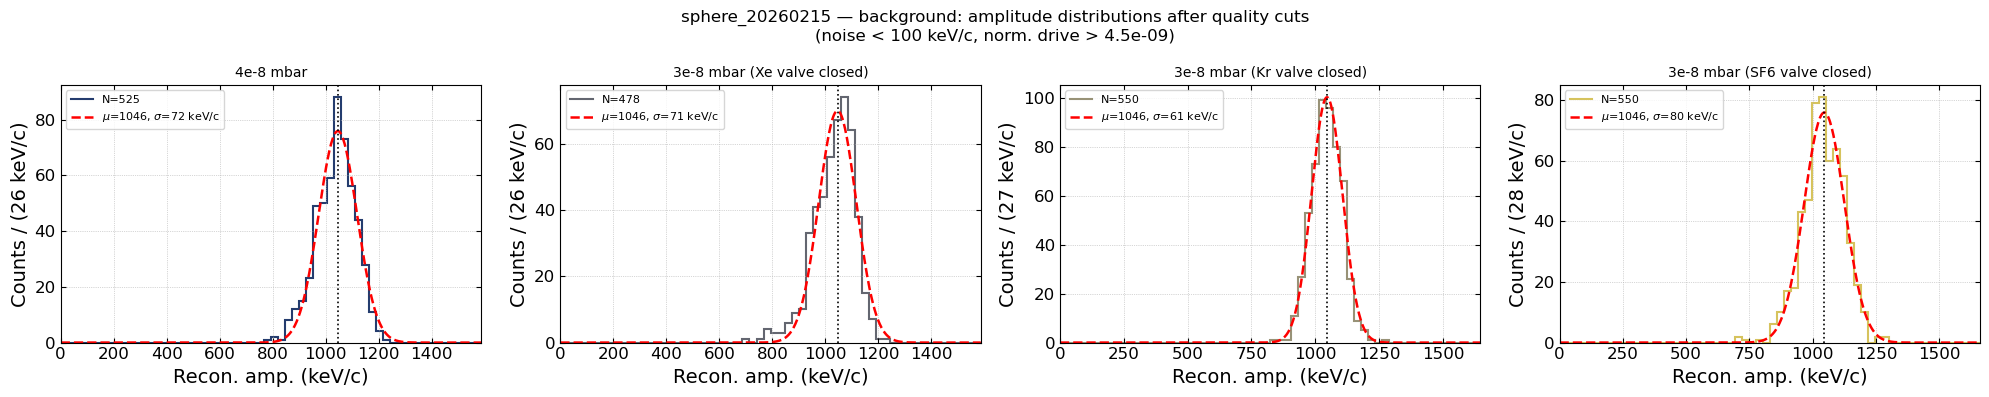

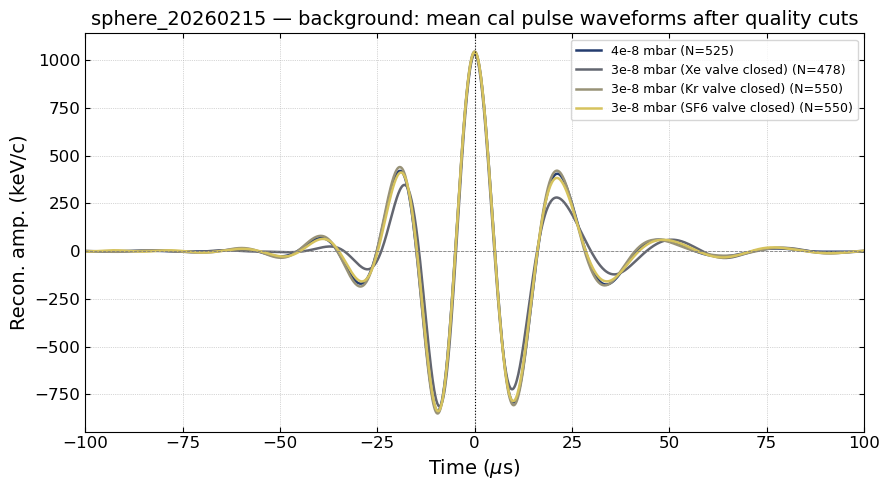

  20260219_p6e_4e-8mbar: 525 pulses, amp2kev=12794, σ=72 keV/c → saved
  20260219_p6e_3e-8mbar_xevalveclosed: 478 pulses, amp2kev=10583, σ=71 keV/c → saved
  20260219_p6e_3e-8mbar_krvalveclosed: 550 pulses, amp2kev=12955, σ=61 keV/c → saved
  20260219_p6e_3e-8mbar_sf6valveclosed: 550 pulses, amp2kev=12454, σ=80 keV/c → saved

Written: /Users/yuhan/work/nanospheres/gas_collisions/data_processed/gas_data_processed/sphere_20260215/background_data/sphere_20260215_background_cal_summary.hdf5


In [55]:
# ── Apply quality cuts, re-fit, plot histograms + waveforms, save ─────────

dtt_ref = 200e-9   # 5 MHz

bg_loaded_cut = []
for e in bg_loaded:
    a2k_plot = e['a2k'] if e['a2k'] is not None else amp2kev_cal
    mask = apply_quality_cuts(e['noise_kev'], e['norm_drive'], noise_cut_kev, drive_cut)
    n_before, n_after = len(e['data']['amplitude']), int(mask.sum())
    print(f'{e["label"]}: {n_after}/{n_before} pulses pass cuts ({100*n_after/n_before:.1f}%)')

    amps_sel = e['data']['amplitude'][mask]
    wavs_sel = e['data']['waveform'][mask]

    bins_cut, hh_cut, gp_cut, a2k_cut = fit_gaussian_amps(amps_sel, expected_kev)
    a2k_final = a2k_cut if a2k_cut is not None else a2k_plot
    if gp_cut is not None:
        print(f'  amp2kev = {a2k_cut:.0f}  (was {a2k_plot:.0f}),  '
              f'μ = {gp_cut[1]*a2k_cut:.0f},  σ = {gp_cut[2]*a2k_cut:.0f} keV/c')

    bg_loaded_cut.append(dict(
        dataset=e['dataset'], label=e['label'], color=e['color'],
        amps_raw=amps_sel, wavs_raw=wavs_sel,
        amps_kev=amps_sel * a2k_final, wavs_kev=wavs_sel * a2k_final,
        bins_cut=bins_cut, hh_cut=hh_cut, gp=gp_cut, a2k=a2k_cut,
        c_imp_scaling=e['data']['c_imp_scaling'],
    ))

# ── Figure 1: amplitude histograms after cuts ─────────────────────────────
n_ds  = len(bg_loaded_cut)
ncols = min(n_ds, 4)
nrows = (n_ds + ncols - 1) // ncols

fig1, axes1 = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes1_flat = np.array(axes1).flatten() if n_ds > 1 else [axes1]

for ax, e in zip(axes1_flat, bg_loaded_cut):
    a2k_plot = e['a2k'] if e['a2k'] is not None else amp2kev_cal
    bins_kev = e['bins_cut'] * a2k_plot
    ax.stairs(e['hh_cut'], edges=bins_kev, color=e['color'], lw=1.5, label=f'N={len(e["amps_kev"])}')
    if e['gp'] is not None:
        xx = np.linspace(0, bins_kev[-1], 500)
        ax.plot(xx, utils.gauss(xx / a2k_plot, *e['gp']), 'r--', lw=1.8,
                label=fr'$\mu$={e["gp"][1]*a2k_plot:.0f}, $\sigma$={e["gp"][2]*a2k_plot:.0f} keV/c')
    ax.axvline(expected_kev, color='k', ls=':', lw=1.2)
    ax.set_title(e['label'], fontsize=10)
    ax.set_xlabel('Recon. amp. (keV/c)')
    ax.set_ylabel(f'Counts / ({bins_kev[1]-bins_kev[0]:.0f} keV/c)')
    ax.set_xlim(0, bins_kev[-1])
    ax.legend(fontsize=8)
    ax.grid(which='both', ls=':', lw=0.5)

for ax in axes1_flat[n_ds:]:
    ax.set_visible(False)

fig1.suptitle(f'{sphere} — background: amplitude distributions after quality cuts\n'
              f'(noise < {noise_cut_kev} keV/c, norm. drive > {drive_cut:.1e})', fontsize=12)
fig1.tight_layout()
plt.show()

# ── Figure 2: mean waveforms after cuts ───────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(9, 5))
for e in bg_loaded_cut:
    whl   = e['wavs_kev'].shape[1] // 2
    tt_us = (np.arange(e['wavs_kev'].shape[1]) - whl) * dtt_ref * 1e6
    ax2.plot(tt_us, e['wavs_kev'].mean(axis=0), color=e['color'], lw=1.8,
             label=f'{e["label"]} (N={len(e["amps_kev"])})')

ax2.axvline(0, color='k', ls=':', lw=0.8)
ax2.axhline(0, color='gray', ls='--', lw=0.6)
ax2.set_xlim(-100, 100)
ax2.set_xlabel(r'Time ($\mu$s)')
ax2.set_ylabel('Recon. amp. (keV/c)')
ax2.set_title(f'{sphere} — background: mean cal pulse waveforms after quality cuts')
ax2.legend(fontsize=9)
ax2.grid(which='both', ls=':', lw=0.5)
fig2.tight_layout()
plt.show()

# ── Save to HDF5 ──────────────────────────────────────────────────────────
out_path = os.path.join(gas_dir, 'background_data', f'{sphere}_background_cal_summary.hdf5')
save_cal_summary_hdf5(out_path, bg_loaded_cut, sphere, noise_cut_kev, drive_cut, expected_kev)

## Krypton datasets — calibration pulse amplitudes and noise

1e-6 mbar: 550 pulses, c_imp=0.3333, amp2kev=9991, μ=1046, σ=72 keV/c
7e-7 mbar: 550 pulses, c_imp=0.2, amp2kev=10603, μ=1046, σ=125 keV/c
5e-7 mbar: 550 pulses, c_imp=0.1, amp2kev=9364, μ=1046, σ=74 keV/c
2e-7 mbar: 550 pulses, c_imp=0.2, amp2kev=10996, μ=1046, σ=67 keV/c
1e-7 mbar: 550 pulses, c_imp=0.3333, amp2kev=14106, μ=1046, σ=63 keV/c
7e-8 mbar: 550 pulses, c_imp=0.3333, amp2kev=14347, μ=1046, σ=52 keV/c
5e-8 mbar: 551 pulses, c_imp=0.3333, amp2kev=13820, μ=1046, σ=59 keV/c


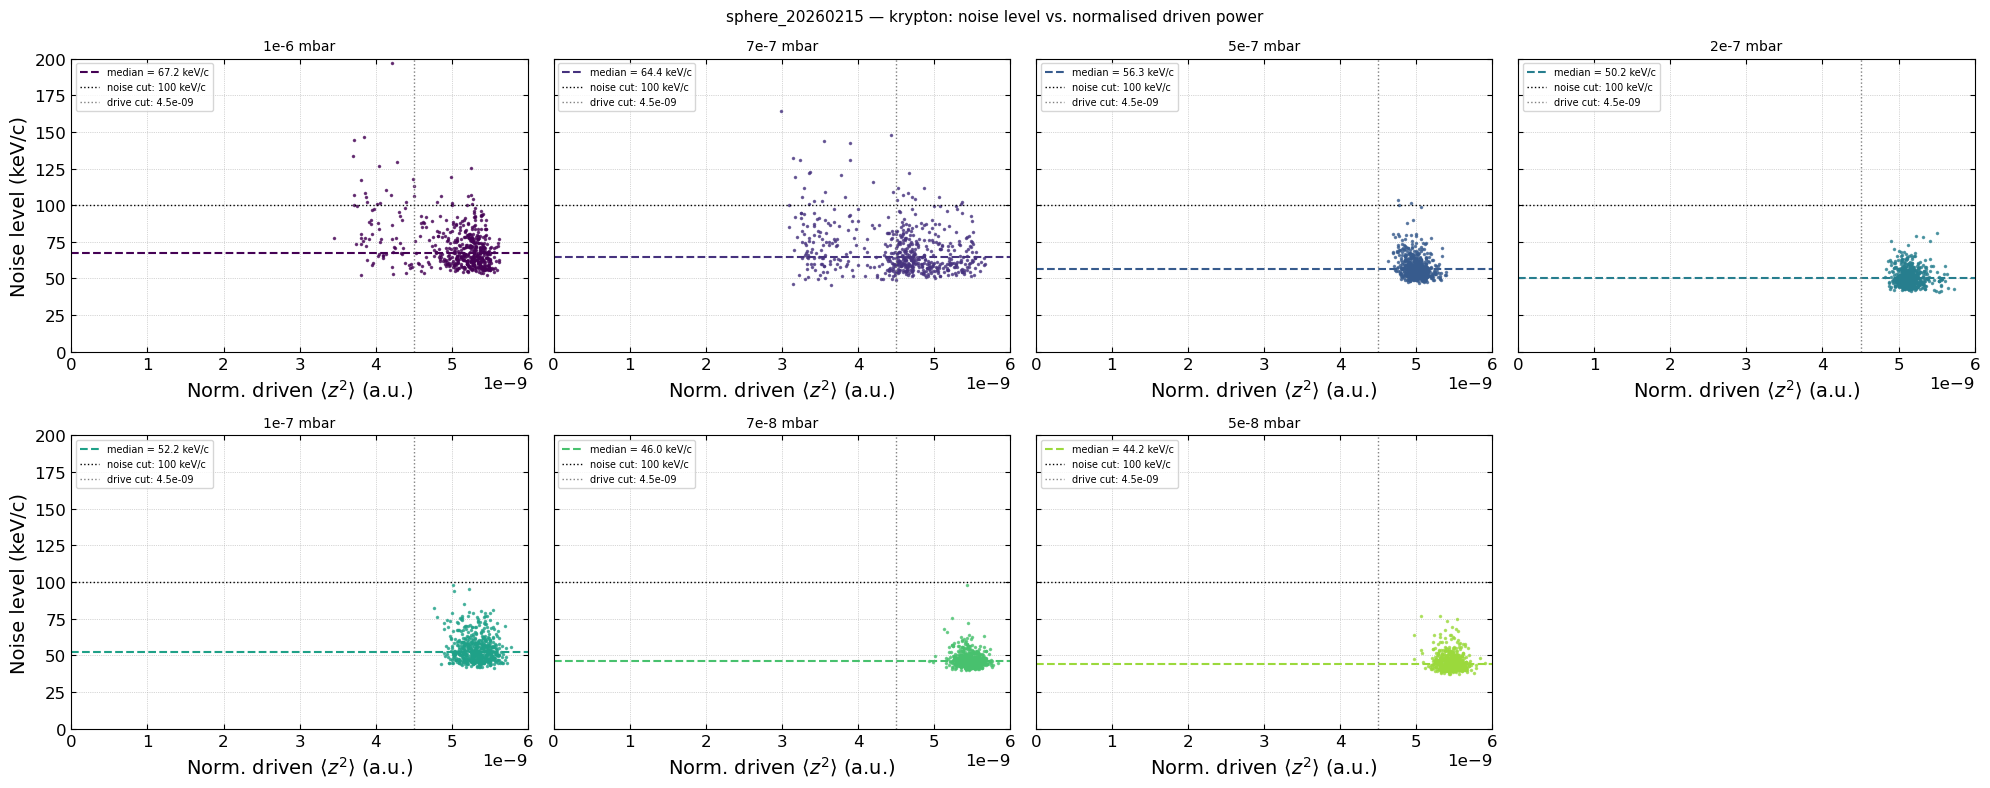

In [56]:
# ── Load krypton cal_processed.hdf5 and plot noise vs. driven power ────────

kr_datasets = [
    ('20260219_p6e_1e-6mbar', '1e-6 mbar'),
    ('20260219_p6e_7e-7mbar', '7e-7 mbar'),
    ('20260219_p6e_5e-7mbar', '5e-7 mbar'),
    ('20260219_p6e_2e-7mbar', '2e-7 mbar'),
    ('20260219_p6e_1e-7mbar', '1e-7 mbar'),
    ('20260219_p6e_7e-8mbar', '7e-8 mbar'),
    ('20260219_p6e_5e-8mbar', '5e-8 mbar'),
]
kr_colors = plt.colormaps['viridis'](np.linspace(0, 0.85, len(kr_datasets)))

kr_loaded = []
for (dataset, label), color in zip(kr_datasets, kr_colors):
    cal_path = os.path.join(gas_dir, 'krypton_data', dataset, f'{dataset}_cal_processed.hdf5')
    if not os.path.exists(cal_path):
        print(f'Missing: {cal_path}')
        continue
    data = load_cal_processed(cal_path)
    bins_raw, hh, gp, a2k = fit_gaussian_amps(data['amplitude'], expected_kev)
    a2k_plot   = a2k if a2k is not None else amp2kev_cal
    noise_kev  = data['noise_level'] * a2k_plot
    norm_drive = compute_norm_drive(data['driven_power'], data['f_res'], drive_freq, ref_freq)
    print(f'{label}: {len(data["amplitude"])} pulses, c_imp={data["c_imp_scaling"]:.4g}'
          + (f', amp2kev={a2k:.0f}, μ={gp[1]*a2k:.0f}, σ={gp[2]*a2k:.0f} keV/c' if gp is not None else ''))
    kr_loaded.append(dict(dataset=dataset, label=label, color=color,
                          data=data, bins_raw=bins_raw, hh=hh, gp=gp, a2k=a2k,
                          noise_kev=noise_kev, norm_drive=norm_drive))

# ── Noise level vs. normalised driven power (cut lines shown) ─────────────
n_ds  = len(kr_loaded)
ncols = 4
nrows = (n_ds + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), sharey=True)
axes_flat = np.array(axes).flatten()

for ax, e in zip(axes_flat, kr_loaded):
    ax.plot(e['norm_drive'], e['noise_kev'], '.', color=e['color'], markersize=3, alpha=0.7)
    ax.axhline(np.median(e['noise_kev']), color=e['color'], lw=1.5, ls='--',
               label=f'median = {np.median(e["noise_kev"]):.1f} keV/c')
    ax.axhline(noise_cut_kev, color='k',    lw=1.0, ls=':', label=f'noise cut: {noise_cut_kev} keV/c')
    ax.axvline(drive_cut,     color='gray', lw=1.0, ls=':', label=f'drive cut: {drive_cut:.1e}')
    ax.set_title(e['label'], fontsize=10)
    ax.set_xlabel(r'Norm. driven $\langle z^2 \rangle$ (a.u.)')
    ax.set_ylim(0, 200)
    ax.set_xlim(0, 6e-9)
    ax.legend(fontsize=7)
    ax.grid(which='both', ls=':', lw=0.5)

for ax in axes_flat[n_ds:]:
    ax.set_visible(False)

axes_flat[0].set_ylabel('Noise level (keV/c)')
if nrows > 1:
    axes_flat[ncols].set_ylabel('Noise level (keV/c)')

fig.suptitle(f'{sphere} — krypton: noise level vs. normalised driven power', fontsize=11)
fig.tight_layout()
plt.show()

1e-6 mbar: 467/550 pulses pass cuts (84.9%)
  amp2kev = 9954  (was 9991),  μ = 1046,  σ = 66 keV/c
7e-7 mbar: 349/550 pulses pass cuts (63.5%)
  amp2kev = 10246  (was 10603),  μ = 1046,  σ = 99 keV/c
5e-7 mbar: 547/550 pulses pass cuts (99.5%)
  amp2kev = 9365  (was 9364),  μ = 1046,  σ = 74 keV/c
2e-7 mbar: 550/550 pulses pass cuts (100.0%)
  amp2kev = 10996  (was 10996),  μ = 1046,  σ = 67 keV/c
1e-7 mbar: 550/550 pulses pass cuts (100.0%)
  amp2kev = 14106  (was 14106),  μ = 1046,  σ = 63 keV/c
7e-8 mbar: 550/550 pulses pass cuts (100.0%)
  amp2kev = 14347  (was 14347),  μ = 1046,  σ = 52 keV/c
5e-8 mbar: 551/551 pulses pass cuts (100.0%)
  amp2kev = 13820  (was 13820),  μ = 1046,  σ = 59 keV/c


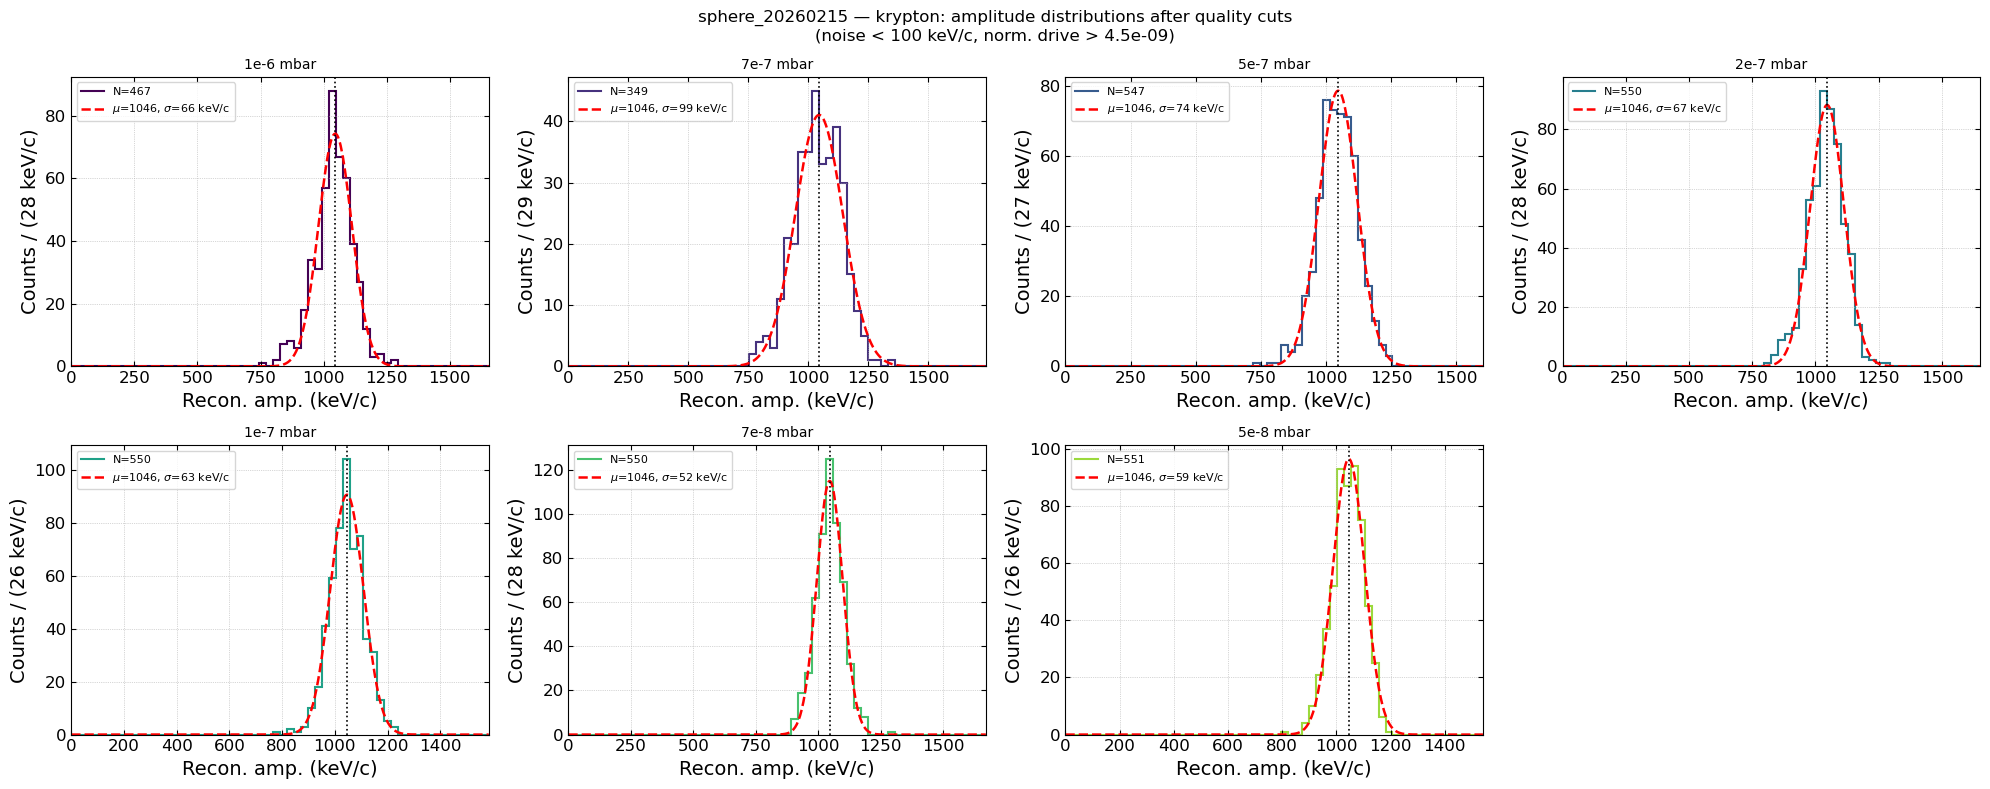

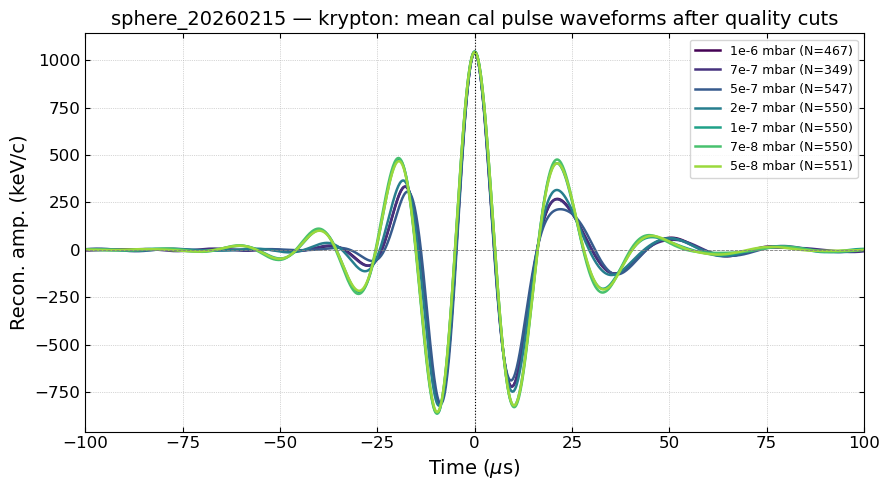

  20260219_p6e_1e-6mbar: 467 pulses, amp2kev=9954, σ=66 keV/c → saved
  20260219_p6e_7e-7mbar: 349 pulses, amp2kev=10246, σ=99 keV/c → saved
  20260219_p6e_5e-7mbar: 547 pulses, amp2kev=9365, σ=74 keV/c → saved
  20260219_p6e_2e-7mbar: 550 pulses, amp2kev=10996, σ=67 keV/c → saved
  20260219_p6e_1e-7mbar: 550 pulses, amp2kev=14106, σ=63 keV/c → saved
  20260219_p6e_7e-8mbar: 550 pulses, amp2kev=14347, σ=52 keV/c → saved
  20260219_p6e_5e-8mbar: 551 pulses, amp2kev=13820, σ=59 keV/c → saved

Written: /Users/yuhan/work/nanospheres/gas_collisions/data_processed/gas_data_processed/sphere_20260215/krypton_data/sphere_20260215_krypton_cal_summary.hdf5


In [57]:
# ── Apply quality cuts, re-fit, plot histograms + waveforms, save ──────────

kr_loaded_cut = []
for e in kr_loaded:
    mask = apply_quality_cuts(e['noise_kev'], e['norm_drive'], noise_cut_kev, drive_cut)
    n_before, n_after = len(e['data']['amplitude']), int(mask.sum())
    print(f'{e["label"]}: {n_after}/{n_before} pulses pass cuts ({100*n_after/n_before:.1f}%)')

    amps_sel = e['data']['amplitude'][mask]
    wavs_sel = e['data']['waveform'][mask]

    bins_cut, hh_cut, gp_cut, a2k_cut = fit_gaussian_amps(amps_sel, expected_kev)
    a2k_final = a2k_cut if a2k_cut is not None else (e['a2k'] if e['a2k'] is not None else amp2kev_cal)
    if gp_cut is not None:
        a2k_prev = e['a2k'] if e['a2k'] is not None else amp2kev_cal
        print(f'  amp2kev = {a2k_cut:.0f}  (was {a2k_prev:.0f}),  '
              f'μ = {gp_cut[1]*a2k_cut:.0f},  σ = {gp_cut[2]*a2k_cut:.0f} keV/c')

    kr_loaded_cut.append(dict(
        dataset=e['dataset'], label=e['label'], color=e['color'],
        amps_raw=amps_sel, wavs_raw=wavs_sel,
        amps_kev=amps_sel * a2k_final, wavs_kev=wavs_sel * a2k_final,
        bins_cut=bins_cut, hh_cut=hh_cut, gp=gp_cut, a2k=a2k_cut,
        c_imp_scaling=e['data']['c_imp_scaling'],
    ))

# ── Figure 1: amplitude histograms after cuts ─────────────────────────────
n_ds  = len(kr_loaded_cut)
ncols = 4
nrows = (n_ds + ncols - 1) // ncols

fig1, axes1 = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes1_flat = np.array(axes1).flatten()

for ax, e in zip(axes1_flat, kr_loaded_cut):
    a2k_plot = e['a2k'] if e['a2k'] is not None else amp2kev_cal
    bins_kev = e['bins_cut'] * a2k_plot
    ax.stairs(e['hh_cut'], edges=bins_kev, color=e['color'], lw=1.5, label=f'N={len(e["amps_kev"])}')
    if e['gp'] is not None:
        xx = np.linspace(0, bins_kev[-1], 500)
        ax.plot(xx, utils.gauss(xx / a2k_plot, *e['gp']), 'r--', lw=1.8,
                label=fr'$\mu$={e["gp"][1]*a2k_plot:.0f}, $\sigma$={e["gp"][2]*a2k_plot:.0f} keV/c')
    ax.axvline(expected_kev, color='k', ls=':', lw=1.2)
    ax.set_title(e['label'], fontsize=10)
    ax.set_xlabel('Recon. amp. (keV/c)')
    ax.set_ylabel(f'Counts / ({bins_kev[1]-bins_kev[0]:.0f} keV/c)')
    ax.set_xlim(0, bins_kev[-1])
    ax.legend(fontsize=8)
    ax.grid(which='both', ls=':', lw=0.5)

for ax in axes1_flat[n_ds:]:
    ax.set_visible(False)

fig1.suptitle(f'{sphere} — krypton: amplitude distributions after quality cuts\n'
              f'(noise < {noise_cut_kev} keV/c, norm. drive > {drive_cut:.1e})', fontsize=12)
fig1.tight_layout()
plt.show()

# ── Figure 2: mean waveforms after cuts ───────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(9, 5))
for e in kr_loaded_cut:
    whl   = e['wavs_kev'].shape[1] // 2
    tt_us = (np.arange(e['wavs_kev'].shape[1]) - whl) * dtt_ref * 1e6
    ax2.plot(tt_us, e['wavs_kev'].mean(axis=0), color=e['color'], lw=1.8,
             label=f'{e["label"]} (N={len(e["amps_kev"])})')

ax2.axvline(0, color='k', ls=':', lw=0.8)
ax2.axhline(0, color='gray', ls='--', lw=0.6)
ax2.set_xlim(-100, 100)
ax2.set_xlabel(r'Time ($\mu$s)')
ax2.set_ylabel('Recon. amp. (keV/c)')
ax2.set_title(f'{sphere} — krypton: mean cal pulse waveforms after quality cuts')
ax2.legend(fontsize=9)
ax2.grid(which='both', ls=':', lw=0.5)
fig2.tight_layout()
plt.show()

# ── Save to HDF5 ──────────────────────────────────────────────────────────
out_path = os.path.join(gas_dir, 'krypton_data', f'{sphere}_krypton_cal_summary.hdf5')
save_cal_summary_hdf5(out_path, kr_loaded_cut, sphere, noise_cut_kev, drive_cut, expected_kev)

## SF6 datasets — calibration pulse amplitudes and noise

1e-6 mbar: 550 pulses, c_imp=0.2, amp2kev=9358, μ=1046, σ=69 keV/c
7e-7 mbar: 550 pulses, c_imp=0.1, amp2kev=9131, μ=1046, σ=62 keV/c
5e-7 mbar: 550 pulses, c_imp=0.2, amp2kev=11245, μ=1046, σ=59 keV/c
3e-7 mbar: 550 pulses, c_imp=0.03333, amp2kev=8663, μ=1046, σ=76 keV/c
1e-7 mbar: 550 pulses, c_imp=0.3333, amp2kev=15213, μ=1046, σ=82 keV/c
7e-8 mbar: 550 pulses, c_imp=0.2, amp2kev=12932, μ=1046, σ=74 keV/c
5e-8 mbar: 551 pulses, c_imp=0.3333, amp2kev=15036, μ=1046, σ=59 keV/c


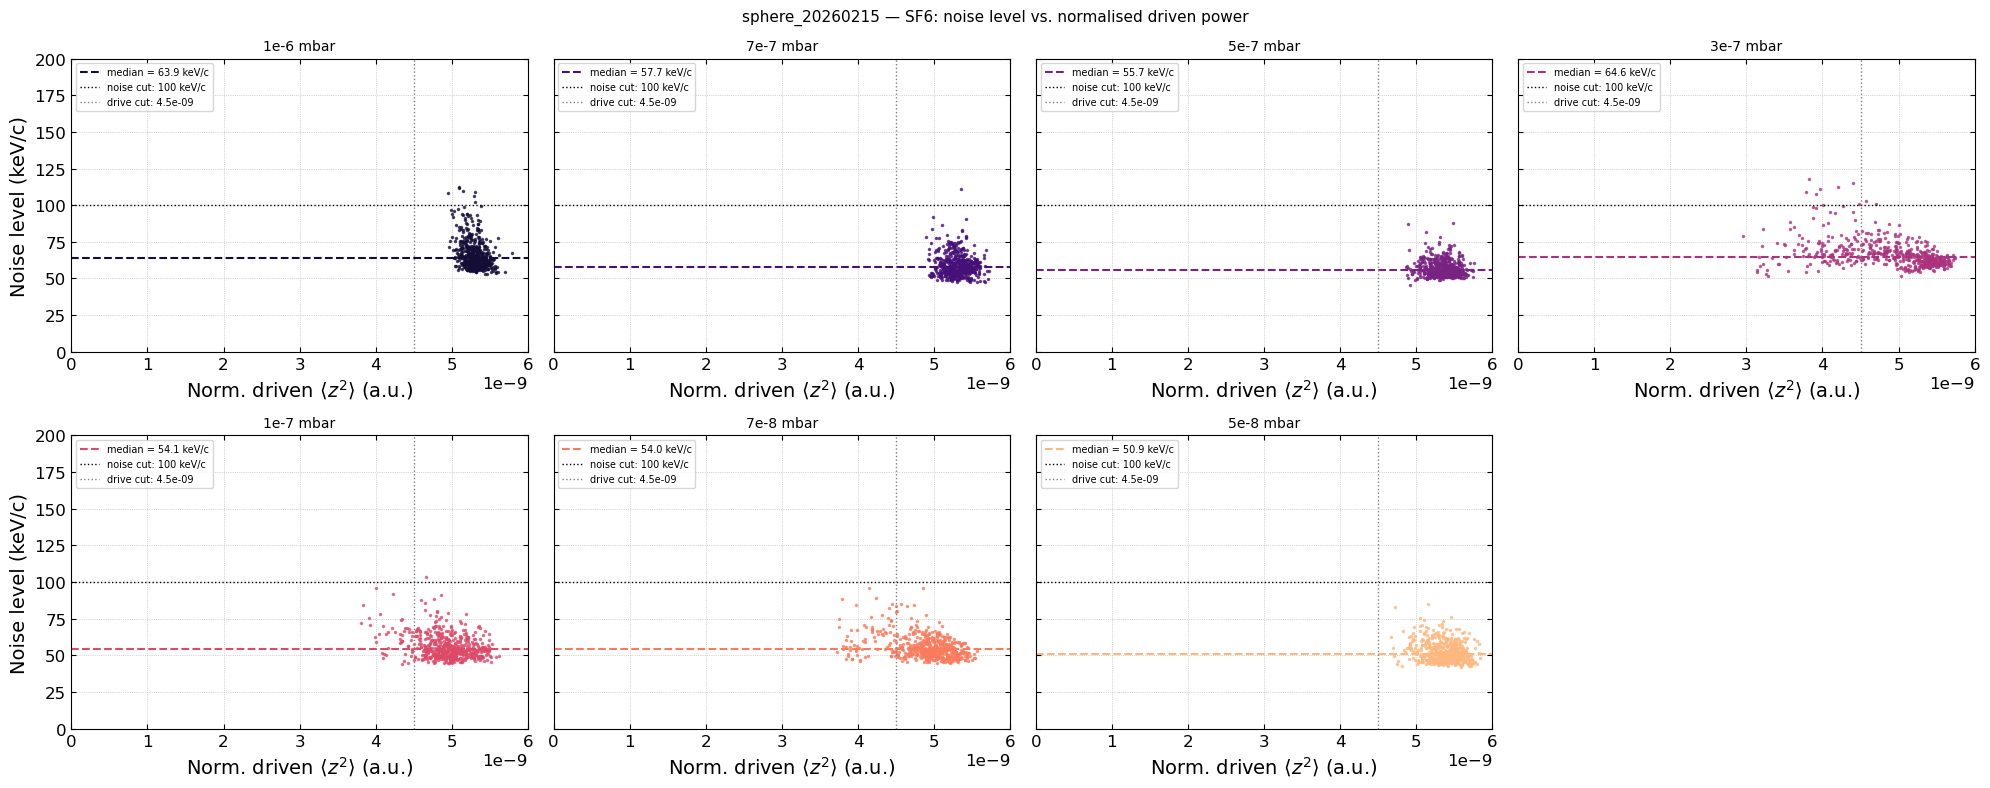

In [58]:
# ── Load SF6 cal_processed.hdf5 and plot noise vs. driven power ────────────

sf6_datasets = [
    ('20260219_p6e_1e-6mbar',   '1e-6 mbar'),
    ('20260219_p6e_7e-7mbar',   '7e-7 mbar'),
    ('20260219_p6e_5e-7mbar',   '5e-7 mbar'),
    ('20260219_p6e_3e-7mbar_1', '3e-7 mbar'),
    ('20260219_p6e_1e-7mbar',   '1e-7 mbar'),
    ('20260219_p6e_7e-8mbar',   '7e-8 mbar'),
    ('20260219_p6e_5e-8mbar',   '5e-8 mbar'),
]
sf6_colors = plt.colormaps['magma'](np.linspace(0.1, 0.85, len(sf6_datasets)))

sf6_loaded = []
for (dataset, label), color in zip(sf6_datasets, sf6_colors):
    cal_path = os.path.join(gas_dir, 'sf6_data', dataset, f'{dataset}_cal_processed.hdf5')
    if not os.path.exists(cal_path):
        print(f'Missing: {cal_path}')
        continue
    data = load_cal_processed(cal_path)
    bins_raw, hh, gp, a2k = fit_gaussian_amps(data['amplitude'], expected_kev)
    a2k_plot   = a2k if a2k is not None else amp2kev_cal
    noise_kev  = data['noise_level'] * a2k_plot
    norm_drive = compute_norm_drive(data['driven_power'], data['f_res'], drive_freq, ref_freq)
    print(f'{label}: {len(data["amplitude"])} pulses, c_imp={data["c_imp_scaling"]:.4g}'
          + (f', amp2kev={a2k:.0f}, μ={gp[1]*a2k:.0f}, σ={gp[2]*a2k:.0f} keV/c' if gp is not None else ''))
    sf6_loaded.append(dict(dataset=dataset, label=label, color=color,
                           data=data, bins_raw=bins_raw, hh=hh, gp=gp, a2k=a2k,
                           noise_kev=noise_kev, norm_drive=norm_drive))

# ── Noise level vs. normalised driven power (cut lines shown) ─────────────
n_ds  = len(sf6_loaded)
ncols = 4
nrows = (n_ds + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), sharey=True)
axes_flat = np.array(axes).flatten()

for ax, e in zip(axes_flat, sf6_loaded):
    ax.plot(e['norm_drive'], e['noise_kev'], '.', color=e['color'], markersize=3, alpha=0.7)
    ax.axhline(np.median(e['noise_kev']), color=e['color'], lw=1.5, ls='--',
               label=f'median = {np.median(e["noise_kev"]):.1f} keV/c')
    ax.axhline(noise_cut_kev, color='k',    lw=1.0, ls=':', label=f'noise cut: {noise_cut_kev} keV/c')
    ax.axvline(drive_cut,     color='gray', lw=1.0, ls=':', label=f'drive cut: {drive_cut:.1e}')
    ax.set_title(e['label'], fontsize=10)
    ax.set_xlabel(r'Norm. driven $\langle z^2 \rangle$ (a.u.)')
    ax.set_ylim(0, 200)
    ax.set_xlim(0, 6e-9)
    ax.legend(fontsize=7)
    ax.grid(which='both', ls=':', lw=0.5)

for ax in axes_flat[n_ds:]:
    ax.set_visible(False)

axes_flat[0].set_ylabel('Noise level (keV/c)')
if nrows > 1:
    axes_flat[ncols].set_ylabel('Noise level (keV/c)')

fig.suptitle(f'{sphere} — SF6: noise level vs. normalised driven power', fontsize=11)
fig.tight_layout()
plt.show()

1e-6 mbar: 543/550 pulses pass cuts (98.7%)
  amp2kev = 9363  (was 9358),  μ = 1046,  σ = 67 keV/c
7e-7 mbar: 549/550 pulses pass cuts (99.8%)
  amp2kev = 9133  (was 9131),  μ = 1046,  σ = 62 keV/c
5e-7 mbar: 550/550 pulses pass cuts (100.0%)
  amp2kev = 11245  (was 11245),  μ = 1046,  σ = 59 keV/c
3e-7 mbar: 409/550 pulses pass cuts (74.4%)
  amp2kev = 8560  (was 8663),  μ = 1046,  σ = 65 keV/c
1e-7 mbar: 502/550 pulses pass cuts (91.3%)
  amp2kev = 15191  (was 15213),  μ = 1046,  σ = 82 keV/c
7e-8 mbar: 471/550 pulses pass cuts (85.6%)
  amp2kev = 12897  (was 12932),  μ = 1046,  σ = 71 keV/c
5e-8 mbar: 551/551 pulses pass cuts (100.0%)
  amp2kev = 15036  (was 15036),  μ = 1046,  σ = 59 keV/c


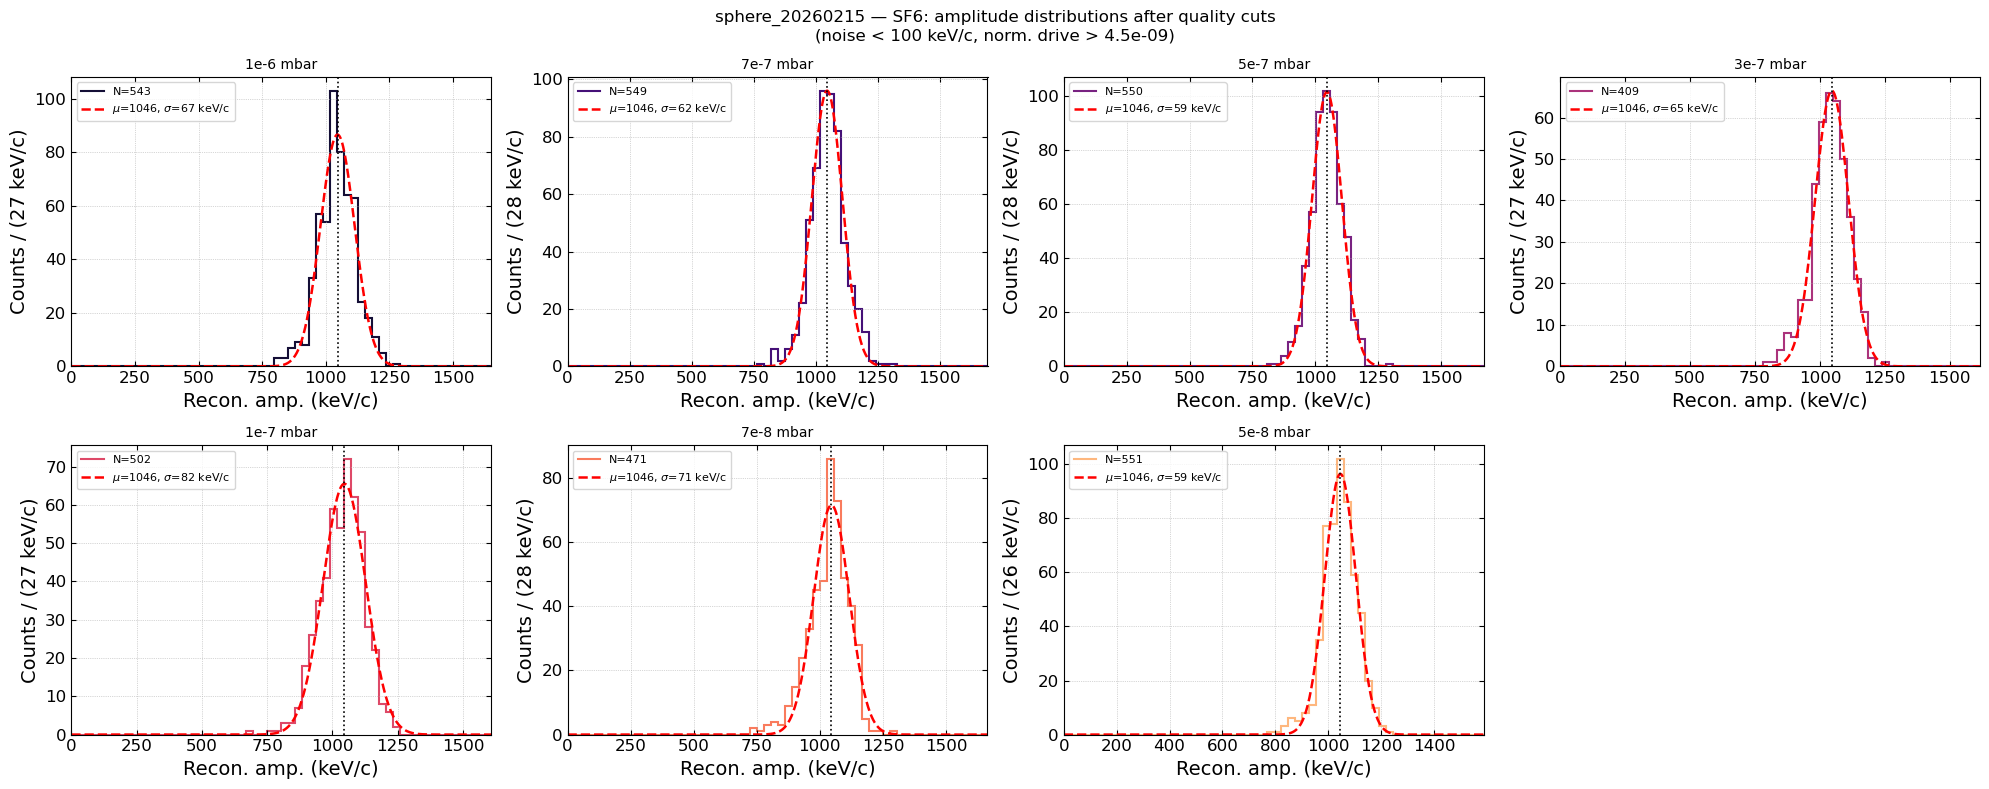

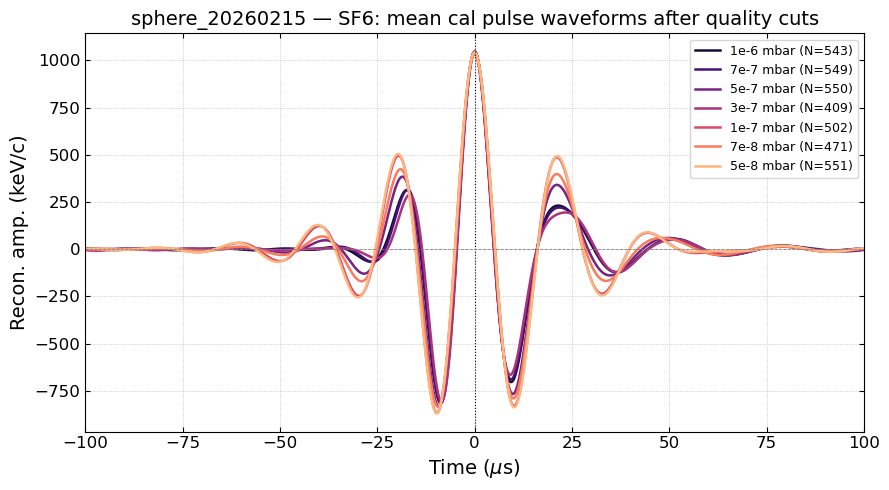

  20260219_p6e_1e-6mbar: 543 pulses, amp2kev=9363, σ=67 keV/c → saved
  20260219_p6e_7e-7mbar: 549 pulses, amp2kev=9133, σ=62 keV/c → saved
  20260219_p6e_5e-7mbar: 550 pulses, amp2kev=11245, σ=59 keV/c → saved
  20260219_p6e_3e-7mbar_1: 409 pulses, amp2kev=8560, σ=65 keV/c → saved
  20260219_p6e_1e-7mbar: 502 pulses, amp2kev=15191, σ=82 keV/c → saved
  20260219_p6e_7e-8mbar: 471 pulses, amp2kev=12897, σ=71 keV/c → saved
  20260219_p6e_5e-8mbar: 551 pulses, amp2kev=15036, σ=59 keV/c → saved

Written: /Users/yuhan/work/nanospheres/gas_collisions/data_processed/gas_data_processed/sphere_20260215/sf6_data/sphere_20260215_sf6_cal_summary.hdf5


In [59]:
# ── Apply quality cuts, re-fit, plot histograms + waveforms, save ──────────

sf6_loaded_cut = []
for e in sf6_loaded:
    mask = apply_quality_cuts(e['noise_kev'], e['norm_drive'], noise_cut_kev, drive_cut)
    n_before, n_after = len(e['data']['amplitude']), int(mask.sum())
    print(f'{e["label"]}: {n_after}/{n_before} pulses pass cuts ({100*n_after/n_before:.1f}%)')

    amps_sel = e['data']['amplitude'][mask]
    wavs_sel = e['data']['waveform'][mask]

    bins_cut, hh_cut, gp_cut, a2k_cut = fit_gaussian_amps(amps_sel, expected_kev)
    a2k_final = a2k_cut if a2k_cut is not None else (e['a2k'] if e['a2k'] is not None else amp2kev_cal)
    if gp_cut is not None:
        a2k_prev = e['a2k'] if e['a2k'] is not None else amp2kev_cal
        print(f'  amp2kev = {a2k_cut:.0f}  (was {a2k_prev:.0f}),  '
              f'μ = {gp_cut[1]*a2k_cut:.0f},  σ = {gp_cut[2]*a2k_cut:.0f} keV/c')

    sf6_loaded_cut.append(dict(
        dataset=e['dataset'], label=e['label'], color=e['color'],
        amps_raw=amps_sel, wavs_raw=wavs_sel,
        amps_kev=amps_sel * a2k_final, wavs_kev=wavs_sel * a2k_final,
        bins_cut=bins_cut, hh_cut=hh_cut, gp=gp_cut, a2k=a2k_cut,
        c_imp_scaling=e['data']['c_imp_scaling'],
    ))

# ── Figure 1: amplitude histograms after cuts ─────────────────────────────
n_ds  = len(sf6_loaded_cut)
ncols = 4
nrows = (n_ds + ncols - 1) // ncols

fig1, axes1 = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes1_flat = np.array(axes1).flatten()

for ax, e in zip(axes1_flat, sf6_loaded_cut):
    a2k_plot = e['a2k'] if e['a2k'] is not None else amp2kev_cal
    bins_kev = e['bins_cut'] * a2k_plot
    ax.stairs(e['hh_cut'], edges=bins_kev, color=e['color'], lw=1.5, label=f'N={len(e["amps_kev"])}')
    if e['gp'] is not None:
        xx = np.linspace(0, bins_kev[-1], 500)
        ax.plot(xx, utils.gauss(xx / a2k_plot, *e['gp']), 'r--', lw=1.8,
                label=fr'$\mu$={e["gp"][1]*a2k_plot:.0f}, $\sigma$={e["gp"][2]*a2k_plot:.0f} keV/c')
    ax.axvline(expected_kev, color='k', ls=':', lw=1.2)
    ax.set_title(e['label'], fontsize=10)
    ax.set_xlabel('Recon. amp. (keV/c)')
    ax.set_ylabel(f'Counts / ({bins_kev[1]-bins_kev[0]:.0f} keV/c)')
    ax.set_xlim(0, bins_kev[-1])
    ax.legend(fontsize=8)
    ax.grid(which='both', ls=':', lw=0.5)

for ax in axes1_flat[n_ds:]:
    ax.set_visible(False)

fig1.suptitle(f'{sphere} — SF6: amplitude distributions after quality cuts\n'
              f'(noise < {noise_cut_kev} keV/c, norm. drive > {drive_cut:.1e})', fontsize=12)
fig1.tight_layout()
plt.show()

# ── Figure 2: mean waveforms after cuts ───────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(9, 5))
for e in sf6_loaded_cut:
    whl   = e['wavs_kev'].shape[1] // 2
    tt_us = (np.arange(e['wavs_kev'].shape[1]) - whl) * dtt_ref * 1e6
    ax2.plot(tt_us, e['wavs_kev'].mean(axis=0), color=e['color'], lw=1.8,
             label=f'{e["label"]} (N={len(e["amps_kev"])})')

ax2.axvline(0, color='k', ls=':', lw=0.8)
ax2.axhline(0, color='gray', ls='--', lw=0.6)
ax2.set_xlim(-100, 100)
ax2.set_xlabel(r'Time ($\mu$s)')
ax2.set_ylabel('Recon. amp. (keV/c)')
ax2.set_title(f'{sphere} — SF6: mean cal pulse waveforms after quality cuts')
ax2.legend(fontsize=9)
ax2.grid(which='both', ls=':', lw=0.5)
fig2.tight_layout()
plt.show()

# ── Save to HDF5 ──────────────────────────────────────────────────────────
out_path = os.path.join(gas_dir, 'sf6_data', f'{sphere}_sf6_cal_summary.hdf5')
save_cal_summary_hdf5(out_path, sf6_loaded_cut, sphere, noise_cut_kev, drive_cut, expected_kev)